## EDA

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
train_df = pd.read_csv('public_trip_data.csv')
test_df = pd.read_csv('private_trip_data.csv')
event_log = pd.read_csv('public_trip_event_log.csv')
event_attr = pd.read_csv('public_trip_event_attributes.csv')

In [8]:
print("Training Dataset Shape")
print(train_df.shape)

print("Private Test Dataset Shape")
print(test_df.shape)

print("Event Log Shape")
print(event_log.shape)

print("Event Attributes Shape")
print(event_attr.shape)

Training Dataset Shape
(65289, 20)
Private Test Dataset Shape
(21764, 13)
Event Log Shape
(671547, 4)
Event Attributes Shape
(65289, 19)


In [9]:
train_df.head()

,TripID,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,EmployeeNumber,BusinessUnit,HotelNights,NetCosts,Departure_CO2e,Return_CO2e,Hotel_CO2e,Spend_CO2e,TotalCO2e,HighCarbon
0,1,CN,Beijing,IN,New Delhi,12,Business Class Flight,Customer Visit,No,9000,M1000-M5008,Services,1,900,1565.121857,1565.121857,58.9,1472.279257,3189.143714,0
1,3,US,New York,MX,Mexico City,11,First Class Flight,Customer Visit,Yes,6000,M1000-M5030,Sales,2,3600,743.295848,743.295848,38.6,2921.504761,1525.191696,0
2,6,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Conference/Exhibition,No,9000,M1000-M5069,Services,1,450,1053.713528,1053.713528,51.4,743.646219,2158.827056,0
3,7,DE,Berlin,FR,Paris,12,Business Class Flight,Customer Visit,No,10000,M1000-M5095,Executive Management,1,3450,196.262703,196.262703,6.7,3343.160260,399.225407,0
4,8,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Internal Business Trip,No,7000,M1000-M5097,Marketing,2,1500,1053.713528,1053.713528,102.8,2478.820729,2210.227056,0


In [10]:
test_df.head()

,TripID,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,BusinessUnit,HotelNights,NetCosts
0,2,BR,SÃ£o Paulo,ZA,Johannesburg,12,Business Class Flight,Customer Visit,Yes,8000,Sales,6,2400
1,4,CN,Beijing,GB,London,10,Economy Flight,Internal Business Trip,No,8000,Customer Support,3,3150
2,5,AU,Sydney,US,Los Angeles,10,Economy Flight,Conference/Exhibition,No,8000,Marketing,6,3000
3,14,BR,SÃ£o Paulo,US,Miami,10,Economy Flight,Conference/Exhibition,No,8000,Executive Management,2,1350
4,15,DE,Berlin,ES,Madrid,12,Business Class Flight,Conference/Exhibition,Yes,8000,Marketing,2,2850


In [11]:
event_log.head()

,TripID,StepOrder,EventName,EventTimestamp
0,1,1,Book Mode of Transportation,03/21/2024 23:36:20
1,1,2,Book Lodging,03/22/2024 09:16:16
2,1,3,Submit Travel Request,03/22/2024 12:15:19
3,1,4,Travel Request Approved,03/23/2024 08:12:58
4,1,5,Receive Confirmation,03/23/2024 23:42:47


In [12]:
event_attr.head()

,TripID,EmployeeNumber,TravelRequestID,ExpenseRequestID,ExpenseDenialReason,ExpenseReimbursementReason,ExpenseReimbursementAmount,ReasonForTransportCancellation,NewTransportSelection,ReasonForNewTransport,NewHotelSelection,ReasonForNewHotel,NewModeOfTransportation,TransportationPriceDifference,ReasonForTransportationChange,ReasonForDelay,ExtensionLength,DaysPreapproved,ProcessCode
0,1,M1000-M5008,TR000001,EXP000001,NaN,Policy exception approved,267.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,V1
1,3,M1000-M5030,TR000003,EXP000003,NaN,Partial reimbursement,526.90,Personal emergency,Rebooked flight,Better schedule,NaN,NaN,Updated First Class Flight,140.62,Time constraints,NaN,NaN,2,V1
2,6,M1000-M5069,TR000006,EXP000006,NaN,Policy exception approved,487.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Weather delay,NaN,1,V1
3,7,M1000-M5095,TR000007,EXP000007,NaN,Policy exception approved,511.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,V1
4,8,M1000-M5097,TR000008,EXP000008,NaN,Standard travel reimbursement,452.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mechanical issue,NaN,2,V20


In [13]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65289 entries, 0 to 65288
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TripID                    65289 non-null  int64  
 1   DepartureLocationCountry  65289 non-null  object 
 2   DepartureLocationCity     65289 non-null  object 
 3   ArrivalLocationCountry    65289 non-null  object 
 4   ArrivalLocationCity       65289 non-null  object 
 5   ShippingType              65289 non-null  int64  
 6   ShippingTypeDescription   65289 non-null  object 
 7   Purpose                   65289 non-null  object 
 8   OutOfPolicy               65289 non-null  object 
 9   EntitiyCode               65289 non-null  int64  
 10  EmployeeNumber            65289 non-null  object 
 11  BusinessUnit              65289 non-null  object 
 12  HotelNights               65289 non-null  int64  
 13  NetCosts                  65289 non-null  int64  
 14  Depart

In [14]:
print("Number of Columns :", len(train_df.columns))
train_df.columns.tolist()

Number of Columns : 20


['TripID',
 'DepartureLocationCountry',
 'DepartureLocationCity',
 'ArrivalLocationCountry',
 'ArrivalLocationCity',
 'ShippingType',
 'ShippingTypeDescription',
 'Purpose',
 'OutOfPolicy',
 'EntitiyCode',
 'EmployeeNumber',
 'BusinessUnit',
 'HotelNights',
 'NetCosts',
 'Departure_CO2e',
 'Return_CO2e',
 'Hotel_CO2e',
 'Spend_CO2e',
 'TotalCO2e',
 'HighCarbon']

In [15]:
duplicate_rows = train_df.duplicated().sum()
print(f"Duplicate Rows : {duplicate_rows}")

Duplicate Rows : 0


In [16]:
duplicate_tripid = train_df["TripID"].duplicated().sum()
print(f"Duplicate TripIDs : {duplicate_tripid}")

Duplicate TripIDs : 0


In [17]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

Series([], dtype: int64)

In [18]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
TripID,65289.0,43574.366509,25105.293053,1.0,21818.000000,43563.000000,65308.000000,87053.00000
ShippingType,65289.0,11.384567,2.488487,4.0,10.000000,12.000000,13.000000,17.00000
EntitiyCode,65289.0,8011.104474,1414.067067,6000.0,7000.000000,8000.000000,9000.000000,10000.00000
HotelNights,65289.0,2.936237,1.426505,1.0,2.000000,3.000000,4.000000,6.00000
NetCosts,65289.0,2151.651886,1049.117452,300.0,1200.000000,2400.000000,3000.000000,3900.00000
Departure_CO2e,65289.0,1326.672254,1384.375971,0.0,376.822886,931.146675,1708.458757,10503.74608
Return_CO2e,65289.0,1326.430958,1384.302135,0.0,328.042478,931.146675,1708.458757,10503.74608
Hotel_CO2e,65289.0,74.616441,65.805207,6.7,31.200000,49.000000,102.800000,353.40000
Spend_CO2e,65289.0,1618.949794,1524.417153,0.0,431.823967,1183.643136,2453.798762,14459.46039
TotalCO2e,65289.0,2727.719653,2766.271867,6.7,830.135410,1894.493350,3472.917514,21202.49216


In [19]:
train_df.describe(include="object").T

,count,unique,top,freq
DepartureLocationCountry,65289,9,AU,21249
DepartureLocationCity,65289,10,Sydney,21249
ArrivalLocationCountry,65289,20,US,13642
ArrivalLocationCity,65289,26,Miami,7732
ShippingTypeDescription,65289,9,Economy Flight,27295
Purpose,65289,5,Customer Visit,28229
OutOfPolicy,65289,2,No,53284
EmployeeNumber,65289,55494,M1454-M5082,6
BusinessUnit,65289,14,Sales,21890


In [20]:
unique = pd.DataFrame({
    "Unique Values": train_df.nunique(),
    "Data Type": train_df.dtypes
})

unique.sort_values("Unique Values")

,Unique Values,Data Type
HighCarbon,2,int64
OutOfPolicy,2,object
Purpose,5,object
EntitiyCode,5,int64
HotelNights,6,int64
ShippingType,9,int64
ShippingTypeDescription,9,object
DepartureLocationCountry,9,object
DepartureLocationCity,10,object
BusinessUnit,14,object


In [21]:
numerical_columns = train_df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = train_df.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical Features :", len(numerical_columns))
print("Categorical Features :", len(categorical_columns))

Numerical Features : 11
Categorical Features : 9


In [22]:
print("Numerical Features\n")
print(numerical_columns)
print("\n")
print("Categorical Features\n")
print(categorical_columns)

Numerical Features

['TripID', 'ShippingType', 'EntitiyCode', 'HotelNights', 'NetCosts', 'Departure_CO2e', 'Return_CO2e', 'Hotel_CO2e', 'Spend_CO2e', 'TotalCO2e', 'HighCarbon']


Categorical Features

['DepartureLocationCountry', 'DepartureLocationCity', 'ArrivalLocationCountry', 'ArrivalLocationCity', 'ShippingTypeDescription', 'Purpose', 'OutOfPolicy', 'EmployeeNumber', 'BusinessUnit']


In [23]:
train_df["HighCarbon"].value_counts()

HighCarbon
0    48963
1    16326
Name: count, dtype: int64

In [24]:
train_df["HighCarbon"].value_counts(normalize=True)*100

HighCarbon
0    74.994256
1    25.005744
Name: proportion, dtype: float64

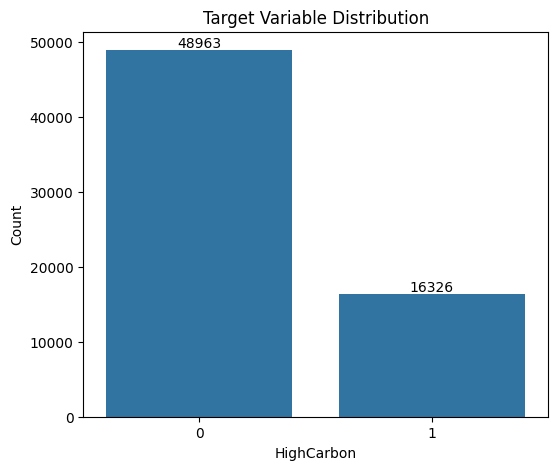

In [25]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=train_df,
    x="HighCarbon"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Target Variable Distribution")

plt.xlabel("HighCarbon")

plt.ylabel("Count")

plt.show()

In [26]:
positive = train_df["HighCarbon"].mean()*100

negative = 100-positive

print(f"High Carbon Trips : {positive:.2f}%")

print(f"Normal Trips : {negative:.2f}%")

High Carbon Trips : 25.01%
Normal Trips : 74.99%


In [27]:
leakage_columns = [
    "Departure_CO2e",
    "Return_CO2e",
    "Hotel_CO2e",
    "Spend_CO2e",
    "TotalCO2e",
    "HighCarbon"
]

print(leakage_columns)

['Departure_CO2e', 'Return_CO2e', 'Hotel_CO2e', 'Spend_CO2e', 'TotalCO2e', 'HighCarbon']


In [28]:
for col in leakage_columns:
    print(f"{col:20} -> {col in train_df.columns}")

Departure_CO2e       -> True
Return_CO2e          -> True
Hotel_CO2e           -> True
Spend_CO2e           -> True
TotalCO2e            -> True
HighCarbon           -> True


## Numerical Feature Insights

- Several numerical features exhibit right-skewed distributions, suggesting the presence of extreme values.
- Boxplots indicate potential outliers in cost- and CO₂-related variables.
- Correlation analysis highlights which variables are most associated with the target; however, CO₂-related columns will be removed before modeling because they are prohibited features.
- Hotel-related and cost-related variables may require transformation or robust imputation in the preprocessing stage.
- The next step is to analyze categorical variables to understand how travel mode, business unit, purpose, and locations relate to high-carbon trips.

In [29]:
exclude_cols = [
    "TripID",
    "HighCarbon",
    "Departure_CO2e",
    "Return_CO2e",
    "Hotel_CO2e",
    "Spend_CO2e",
    "TotalCO2e"
]

num_cols = [col for col in numerical_columns if col not in exclude_cols]

print(f"Number of Numerical Features: {len(num_cols)}")
print(num_cols)

Number of Numerical Features: 4
['ShippingType', 'EntitiyCode', 'HotelNights', 'NetCosts']


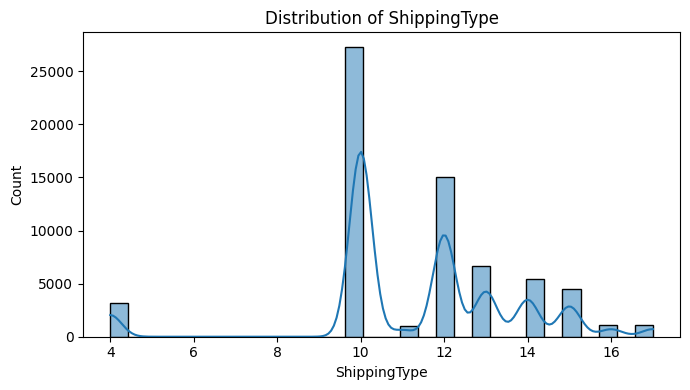

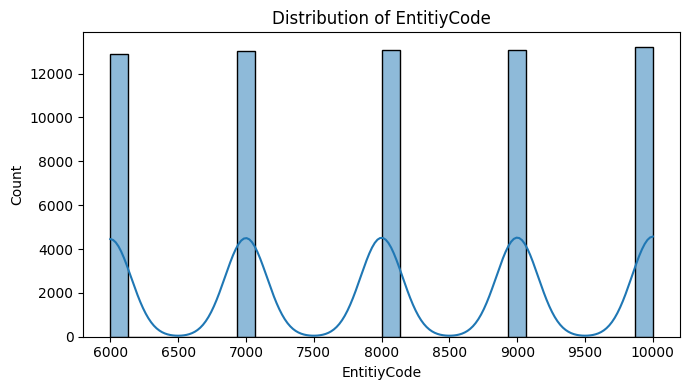

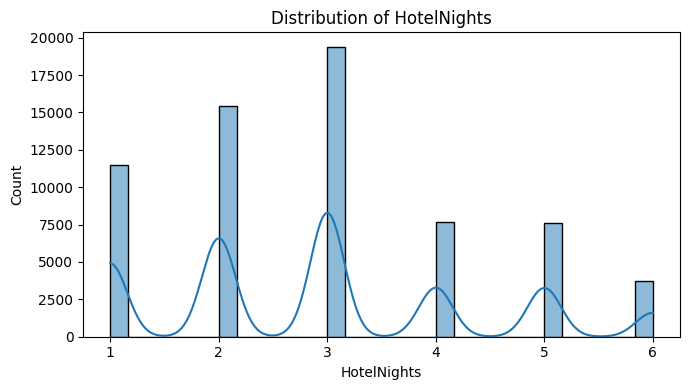

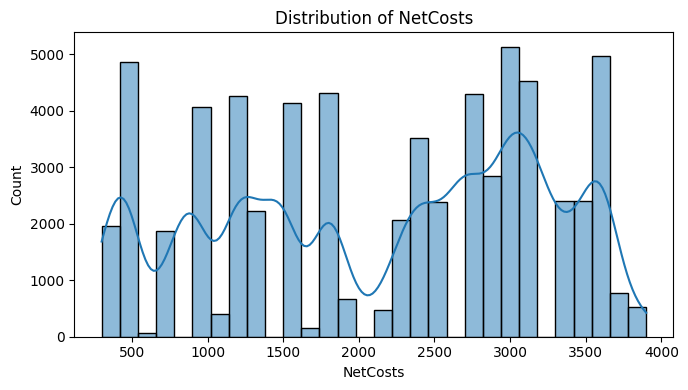

In [30]:
for col in num_cols:

    plt.figure(figsize=(7,4))

    sns.histplot(train_df[col], kde=True, bins=30)

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)

    plt.tight_layout()

    plt.show()

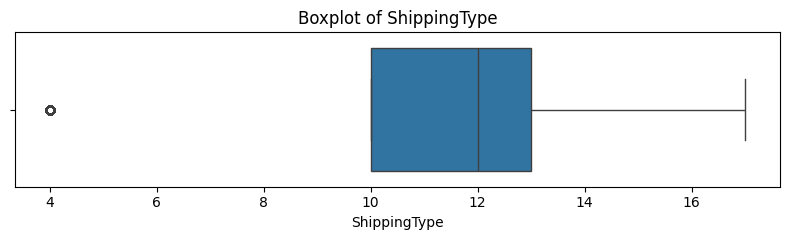

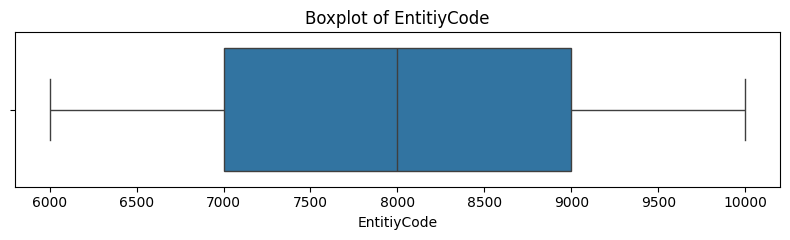

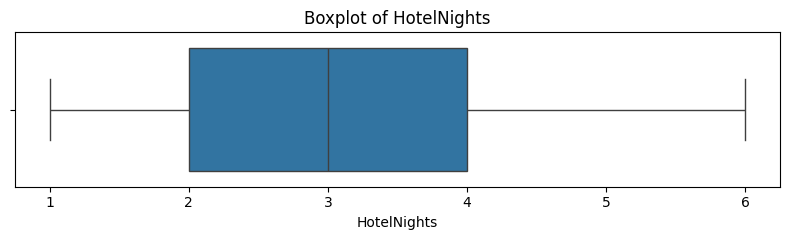

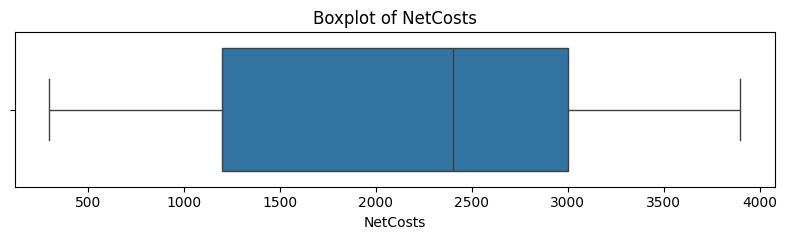

In [31]:
# Outlier detection by Box Plots

for col in num_cols:

    plt.figure(figsize=(8,2.5))

    sns.boxplot(x=train_df[col])

    plt.title(f"Boxplot of {col}")

    plt.tight_layout()

    plt.show()

In [32]:
skewness = train_df[num_cols].skew().sort_values(ascending=False)

skewness = pd.DataFrame(skewness, columns=["Skewness"])

skewness

,Skewness
HotelNights,0.465042
EntitiyCode,-0.008874
NetCosts,-0.226453
ShippingType,-0.708953


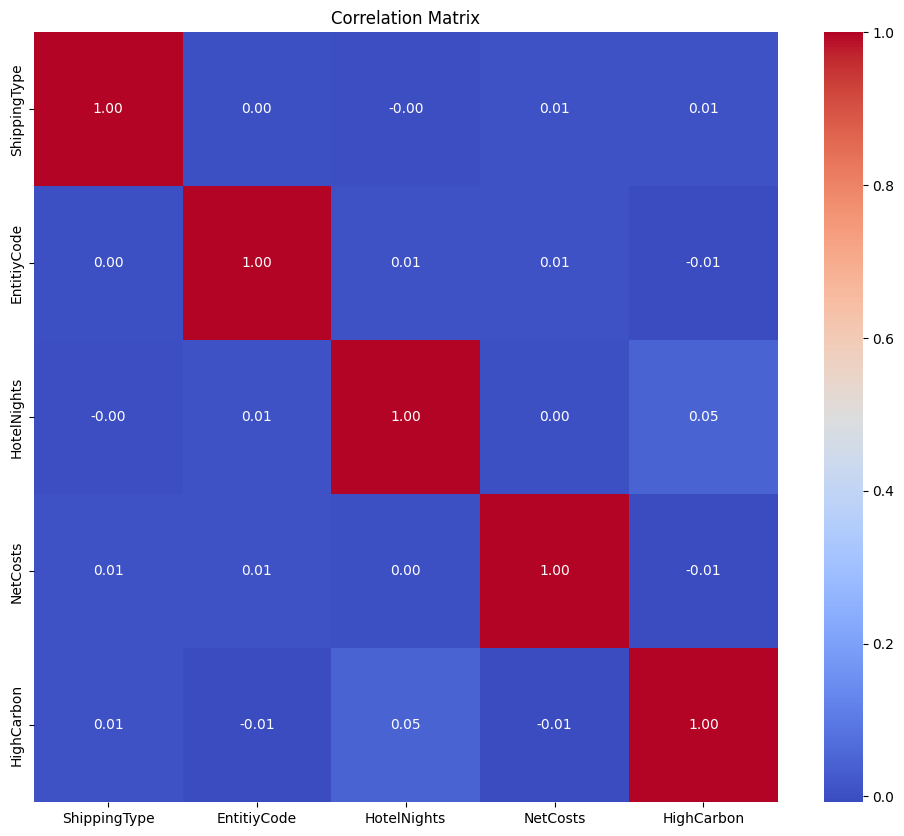

In [33]:
plt.figure(figsize=(12,10))

corr = train_df[num_cols + ["HighCarbon"]].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [34]:
corr_target = (
    train_df[num_cols + ["HighCarbon"]]
    .corr()["HighCarbon"]
    .drop("HighCarbon")
    .sort_values(ascending=False)
)

corr_target

HotelNights     0.046688
ShippingType    0.007100
NetCosts       -0.005511
EntitiyCode    -0.007611
Name: HighCarbon, dtype: float64

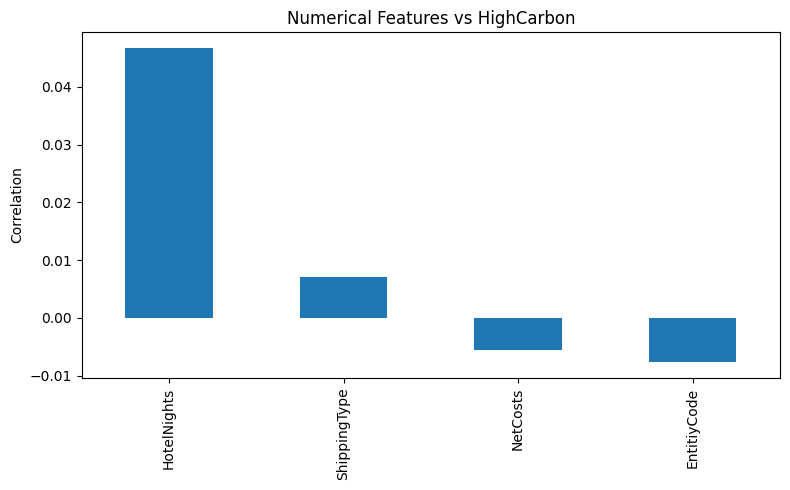

In [35]:
plt.figure(figsize=(8,5))

corr_target.plot(kind="bar")

plt.ylabel("Correlation")

plt.title("Numerical Features vs HighCarbon")

plt.tight_layout()

plt.show()

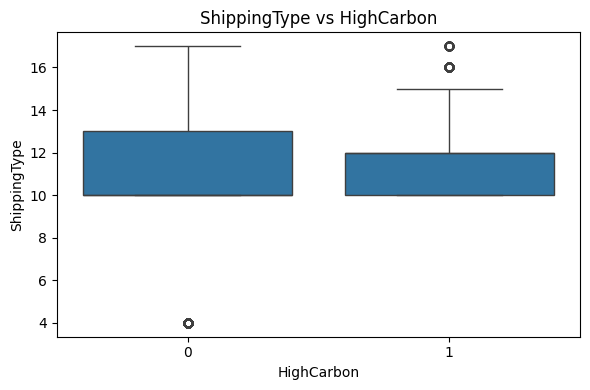

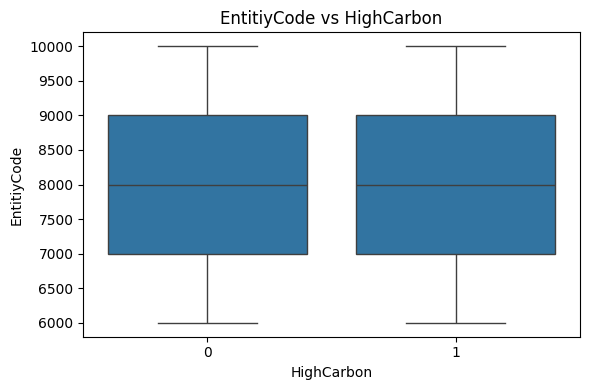

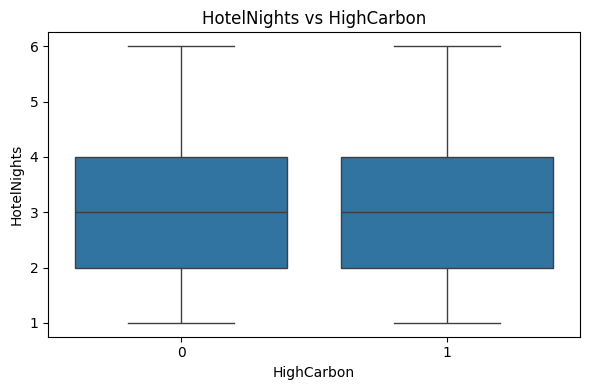

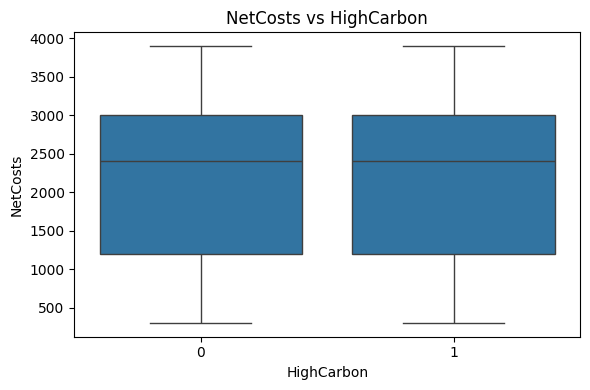

In [36]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=train_df,
        x="HighCarbon",
        y=col
    )

    plt.title(f"{col} vs HighCarbon")

    plt.tight_layout()

    plt.show()

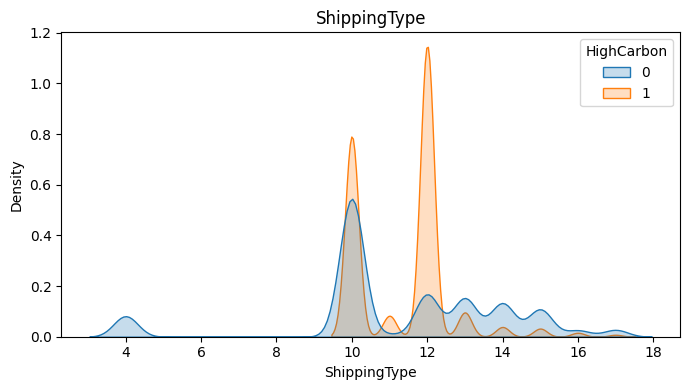

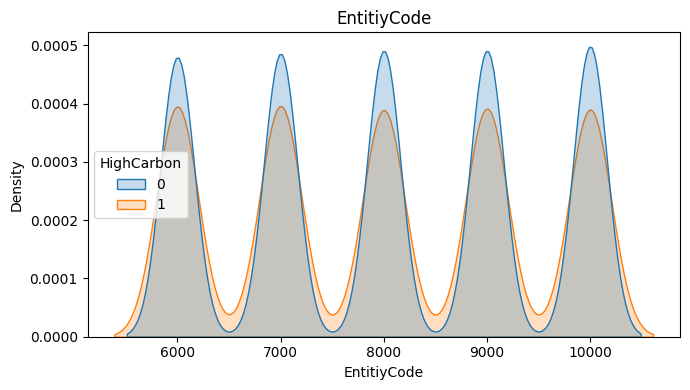

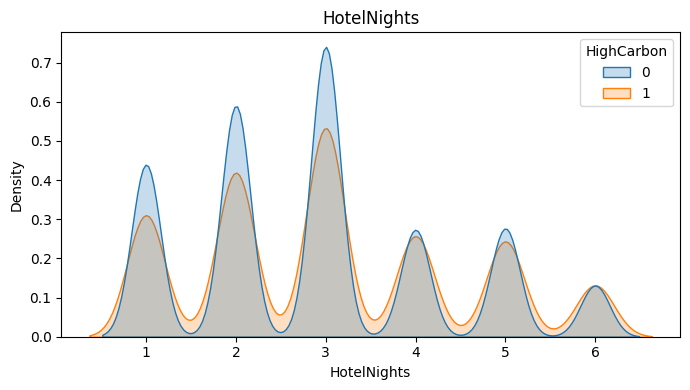

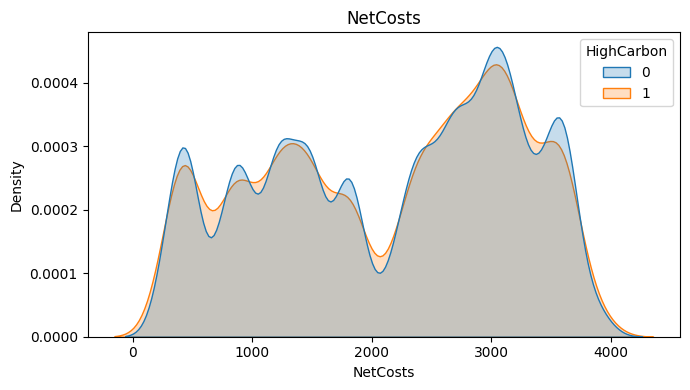

In [37]:
for col in num_cols:

    plt.figure(figsize=(7,4))

    sns.kdeplot(
        data=train_df,
        x=col,
        hue="HighCarbon",
        fill=True,
        common_norm=False
    )

    plt.title(col)

    plt.tight_layout()

    plt.show()

In [38]:
outlier_percentage = {}

for col in num_cols:

    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = (
        (train_df[col] < lower) |
        (train_df[col] > upper)
    ).sum()

    outlier_percentage[col] = round(outliers / len(train_df) * 100, 2)

pd.DataFrame.from_dict(
    outlier_percentage,
    orient="index",
    columns=["Outlier Percentage"]
).sort_values(
    by="Outlier Percentage",
    ascending=False
)

,Outlier Percentage
ShippingType,4.9
EntitiyCode,0.0
HotelNights,0.0
NetCosts,0.0


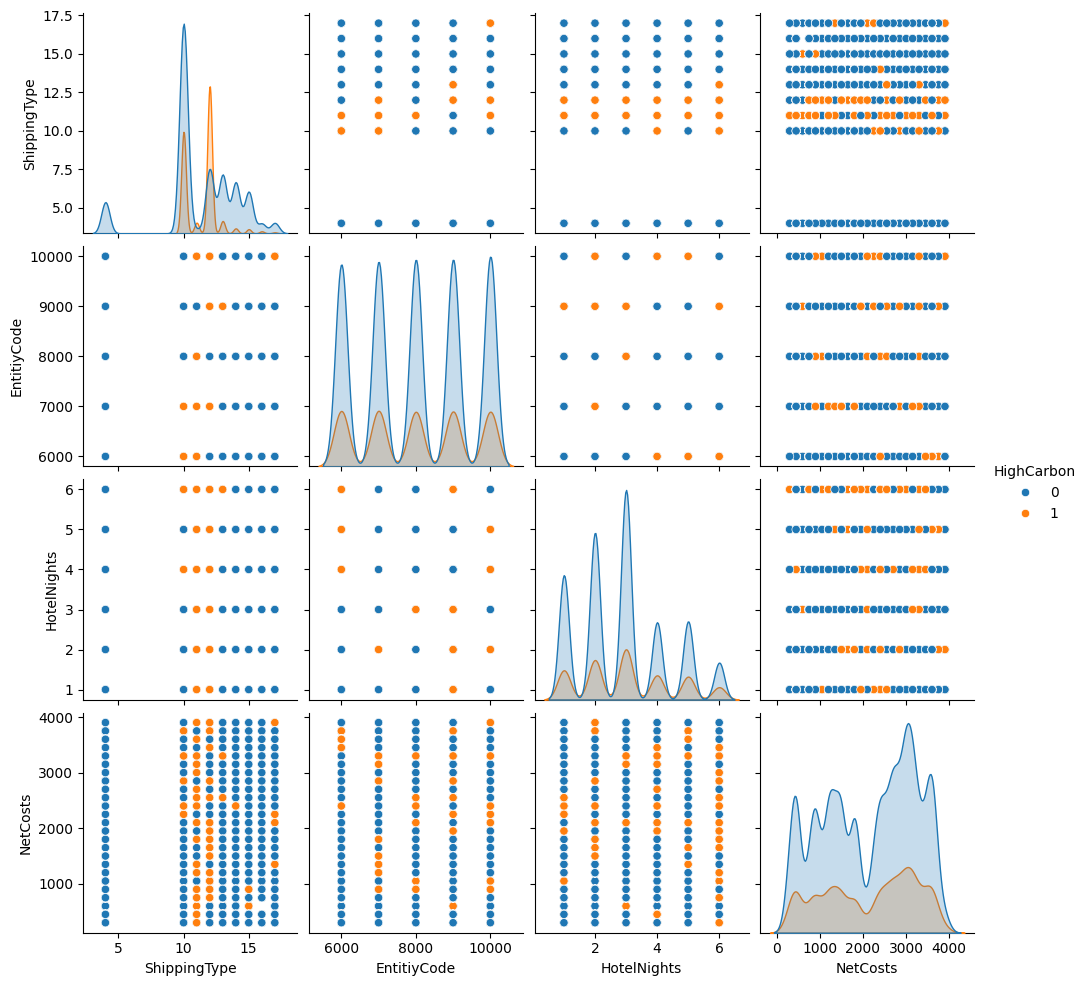

In [39]:
pairplot_cols = num_cols[:4] + ["HighCarbon"]

sns.pairplot(
    train_df[pairplot_cols],
    hue="HighCarbon"
)

plt.show()

In [40]:
unique_cat = pd.DataFrame({
    "Unique Values": train_df[categorical_columns].nunique()
})

unique_cat.sort_values(by="Unique Values", ascending=False)

,Unique Values
EmployeeNumber,55494
ArrivalLocationCity,26
ArrivalLocationCountry,20
BusinessUnit,14
DepartureLocationCity,10
DepartureLocationCountry,9
ShippingTypeDescription,9
Purpose,5
OutOfPolicy,2


In [41]:
for col in categorical_columns:

    print("="*60)
    print(col)
    print("="*60)

    display(train_df[col].value_counts().head(10))

DepartureLocationCountry


DepartureLocationCountry
AU    21249
BR    14674
CN     9130
DE     8759
US     7489
MX     2016
ZA     1411
ES      288
JP      273
Name: count, dtype: int64

DepartureLocationCity


DepartureLocationCity
Sydney         21249
SÃ£o Paulo     14674
Beijing         9130
Berlin          7989
New York        7489
Mexico City     2016
Cape Town       1411
Hamburg          770
Madrid           288
Fukuoka          273
Name: count, dtype: int64

ArrivalLocationCountry


...

OutOfPolicy
No     53284
Yes    12005
Name: count, dtype: int64

EmployeeNumber


EmployeeNumber
M1454-M5082    6
M1474-M5270    5
M1237-M5078    5
M1104-M5105    5
M1157-M5103    5
M1443-M5151    5
M1539-M5203    5
M1064-M5159    5
M1040-M5229    5
M1038-M5455    5
Name: count, dtype: int64

BusinessUnit


BusinessUnit
Sales                   21890
Marketing               12238
Value Engineering        6482
Customer Support         5336
Executive Management     4633
Ecosystem                3492
Services                 3313
Operations               2710
Legal                    1611
Office Management        1427
Name: count, dtype: int64

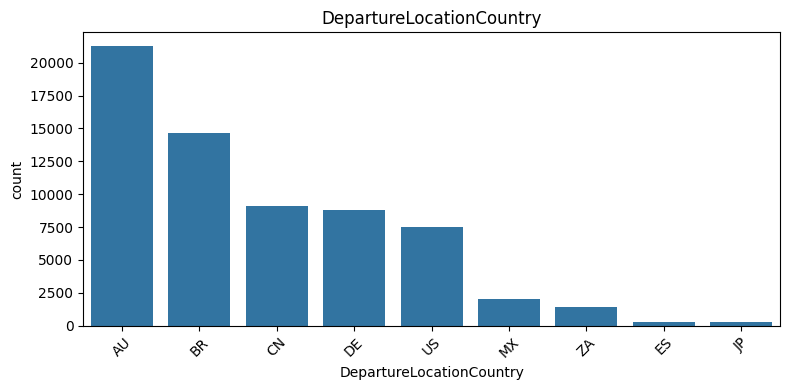

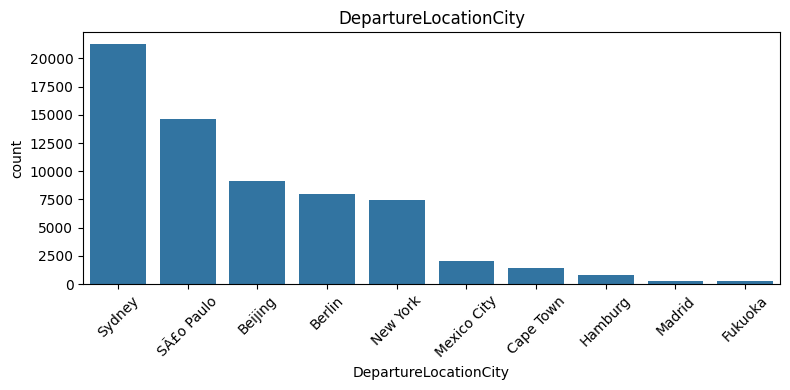

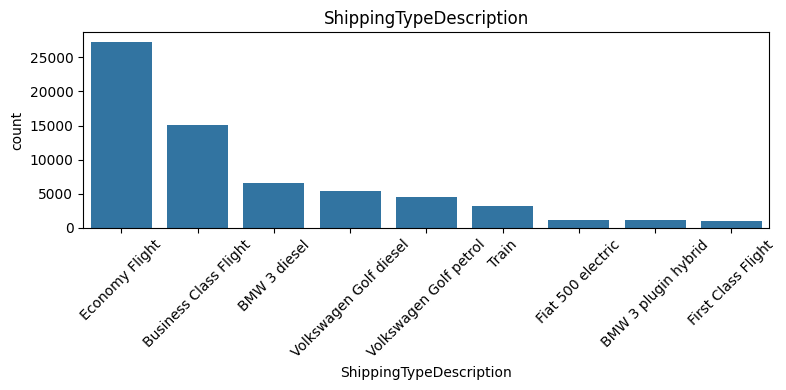

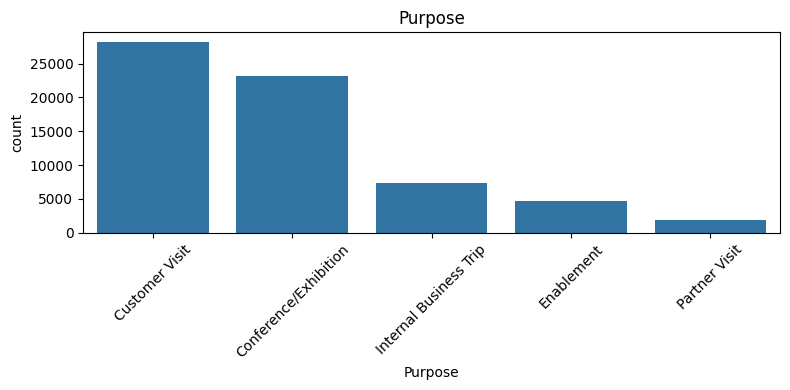

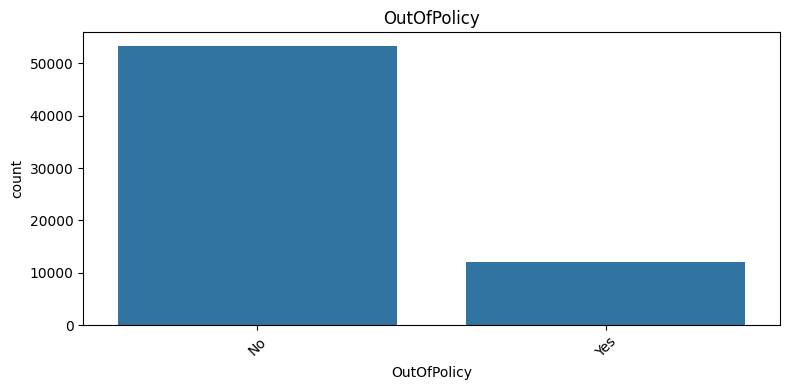

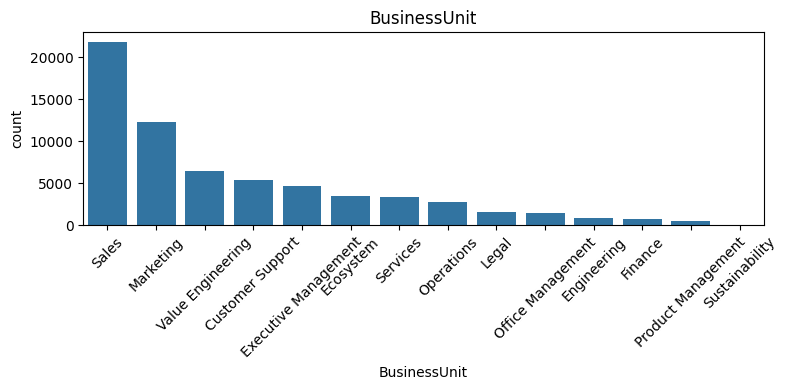

In [42]:
for col in categorical_columns:

    if train_df[col].nunique() <= 15:

        plt.figure(figsize=(8,4))

        sns.countplot(
            data=train_df,
            x=col,
            order=train_df[col].value_counts().index
        )

        plt.xticks(rotation=45)

        plt.title(col)

        plt.tight_layout()

        plt.show()

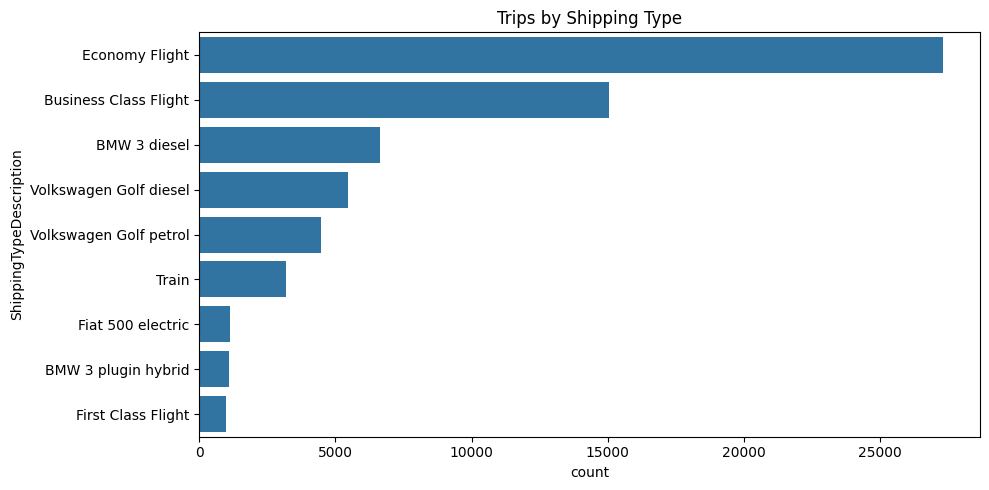

In [43]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train_df,
    y="ShippingTypeDescription",
    order=train_df["ShippingTypeDescription"].value_counts().index
)

plt.title("Trips by Shipping Type")

plt.tight_layout()

plt.show()

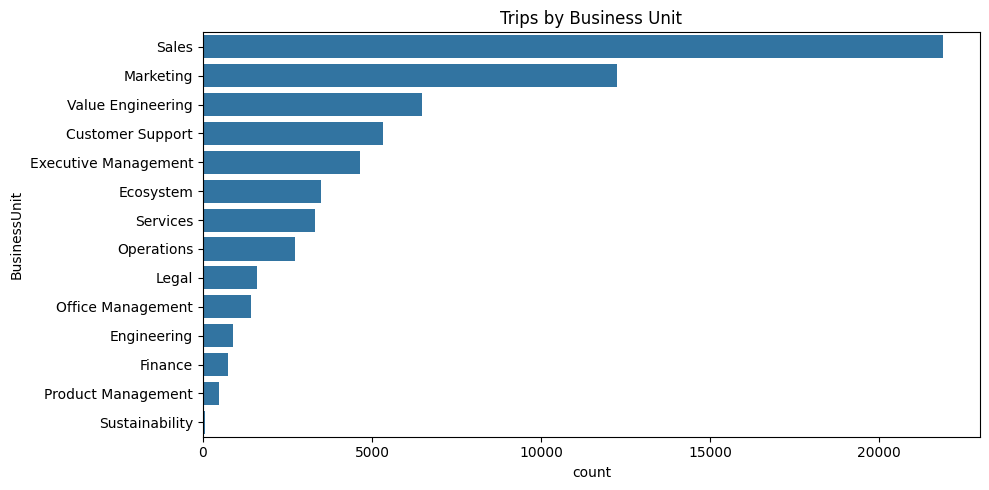

In [44]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train_df,
    y="BusinessUnit",
    order=train_df["BusinessUnit"].value_counts().index
)

plt.title("Trips by Business Unit")

plt.tight_layout()

plt.show()

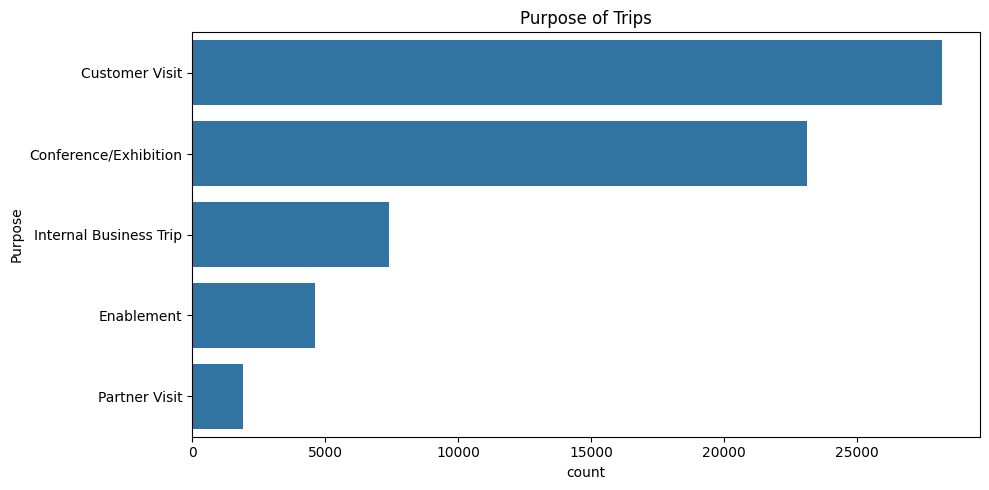

In [45]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train_df,
    y="Purpose",
    order=train_df["Purpose"].value_counts().index
)

plt.title("Purpose of Trips")

plt.tight_layout()

plt.show()

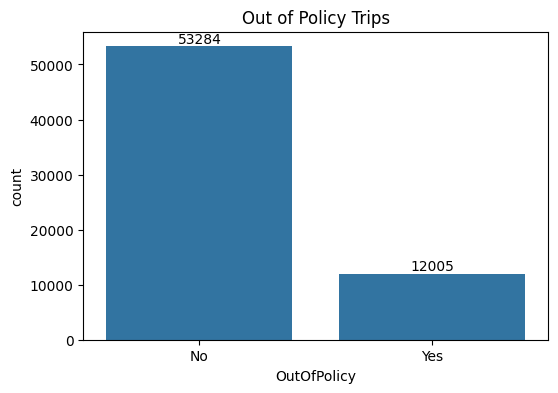

In [46]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=train_df,
    x="OutOfPolicy"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Out of Policy Trips")

plt.show()

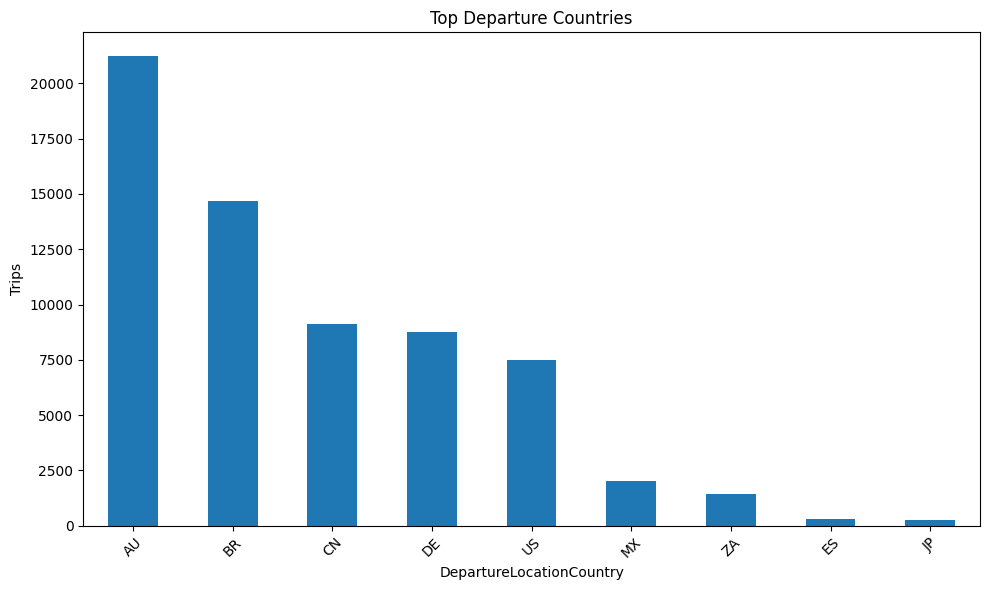

In [47]:
plt.figure(figsize=(10,6))

train_df["DepartureLocationCountry"].value_counts().head(15).plot(kind="bar")

plt.title("Top Departure Countries")

plt.ylabel("Trips")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

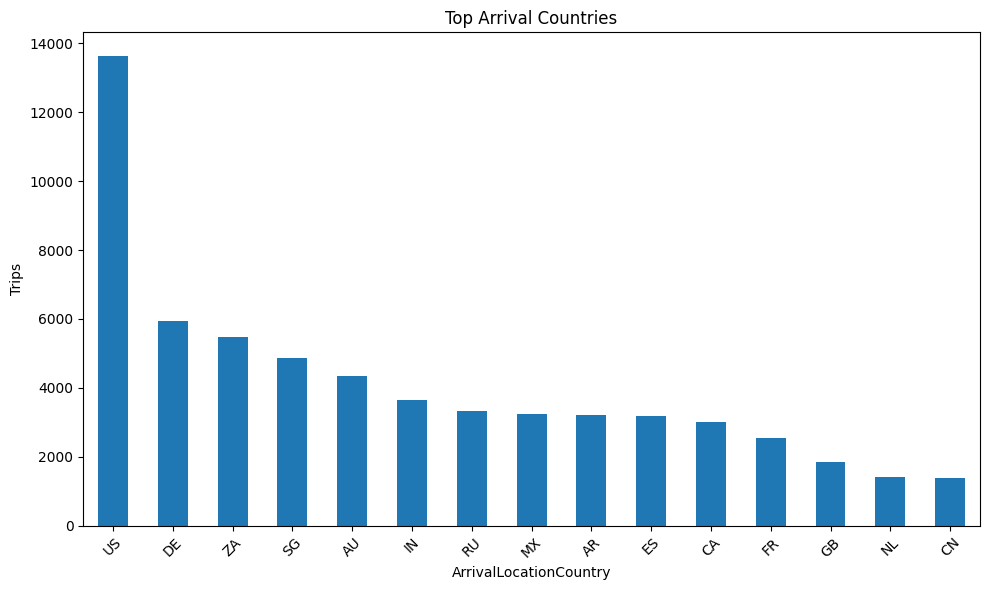

In [48]:
plt.figure(figsize=(10,6))

train_df["ArrivalLocationCountry"].value_counts().head(15).plot(kind="bar")

plt.title("Top Arrival Countries")

plt.ylabel("Trips")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

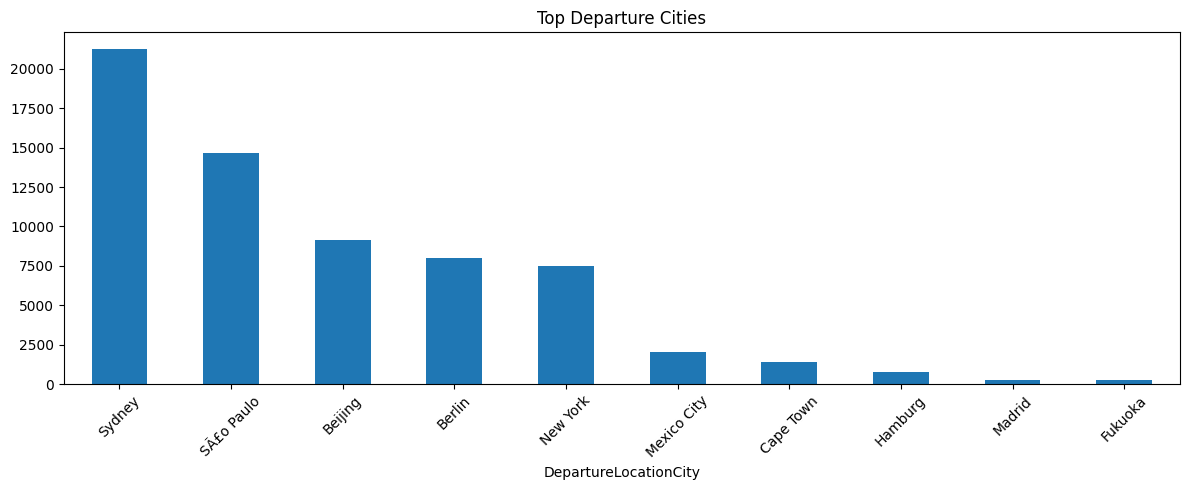

In [49]:
plt.figure(figsize=(12,5))

train_df["DepartureLocationCity"].value_counts().head(20).plot(kind="bar")

plt.title("Top Departure Cities")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

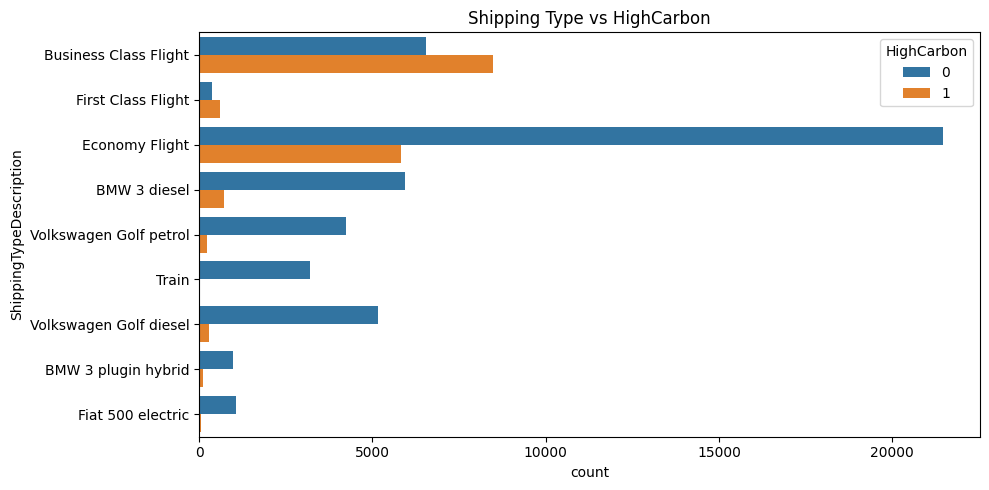

In [50]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train_df,
    y="ShippingTypeDescription",
    hue="HighCarbon"
)

plt.title("Shipping Type vs HighCarbon")

plt.tight_layout()

plt.show()

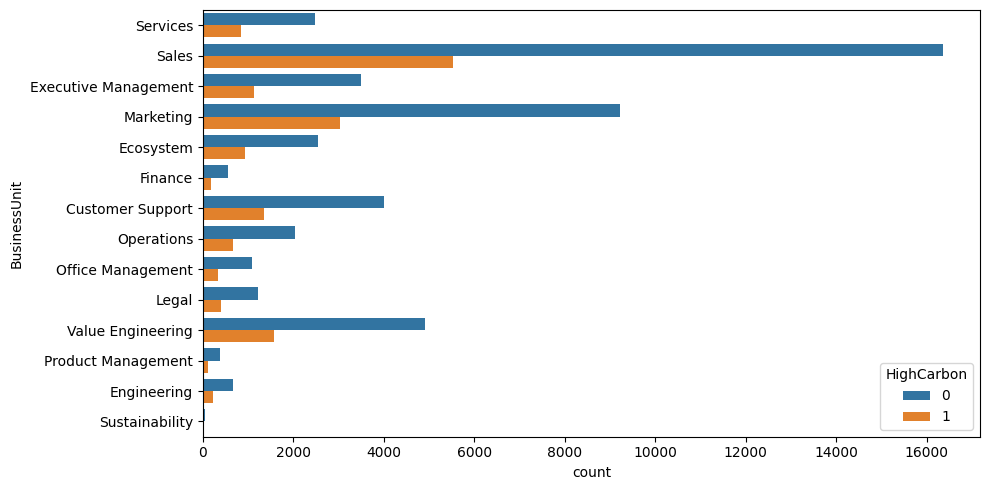

In [51]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train_df,
    y="BusinessUnit",
    hue="HighCarbon"
)

plt.tight_layout()

plt.show()

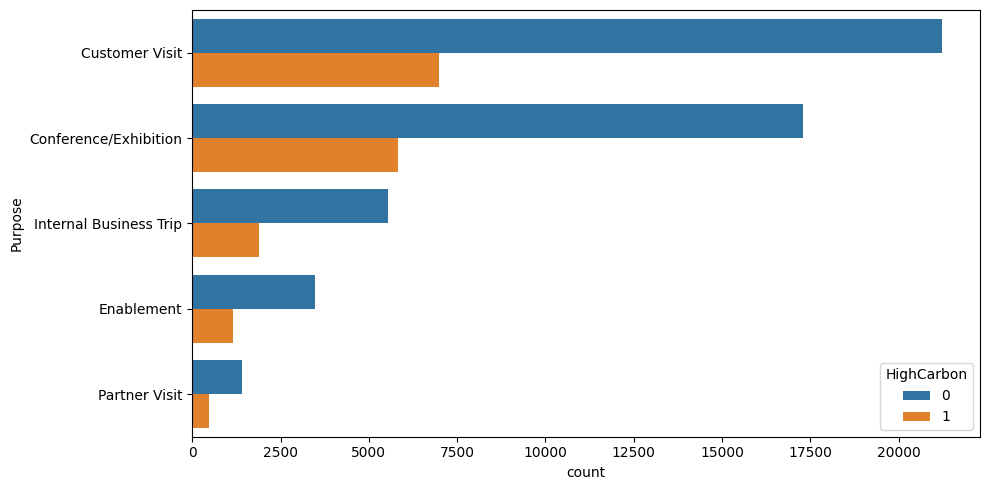

In [52]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train_df,
    y="Purpose",
    hue="HighCarbon"
)

plt.tight_layout()

plt.show()

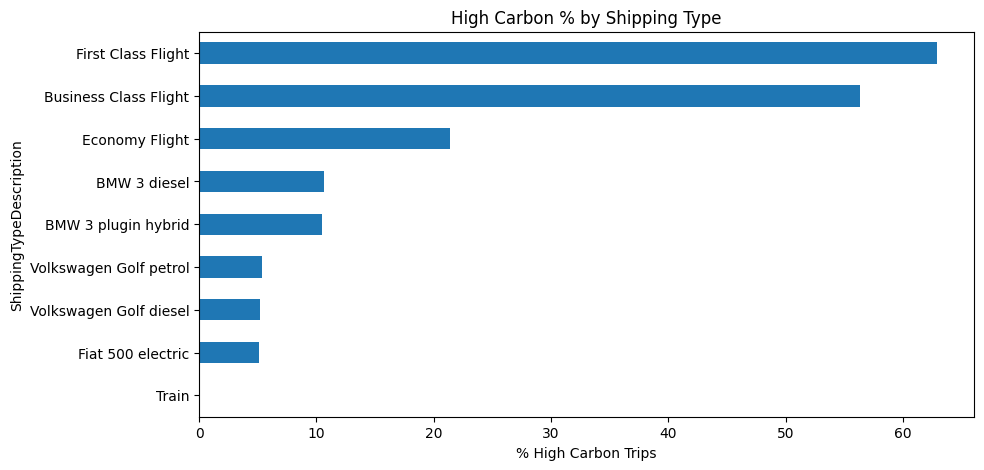

In [53]:
shipping_highcarbon = pd.crosstab(
    train_df["ShippingTypeDescription"],
    train_df["HighCarbon"],
    normalize="index"
) * 100

shipping_highcarbon[1].sort_values().plot(
    kind="barh",
    figsize=(10,5)
)

plt.xlabel("% High Carbon Trips")

plt.title("High Carbon % by Shipping Type")

plt.show()

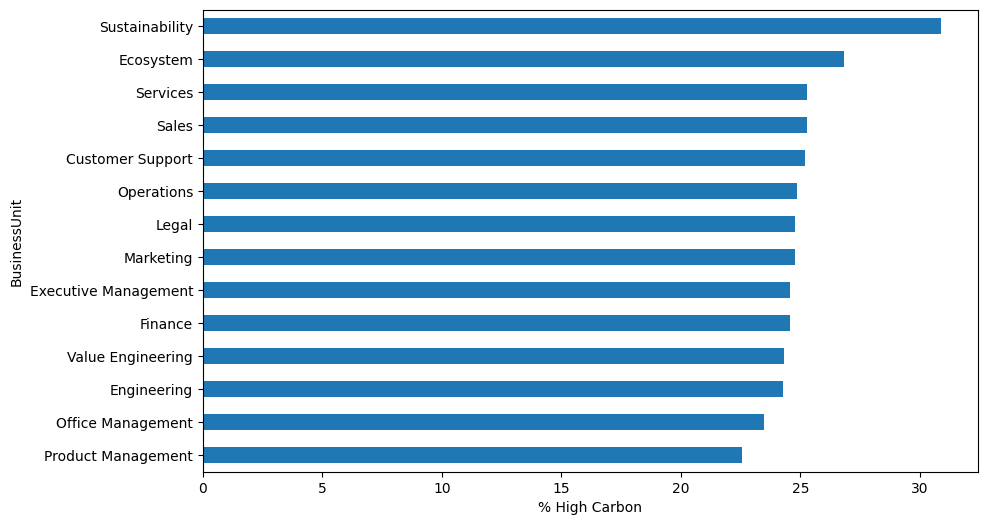

In [54]:
business_highcarbon = pd.crosstab(
    train_df["BusinessUnit"],
    train_df["HighCarbon"],
    normalize="index"
) * 100

business_highcarbon[1].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.xlabel("% High Carbon")

plt.show()

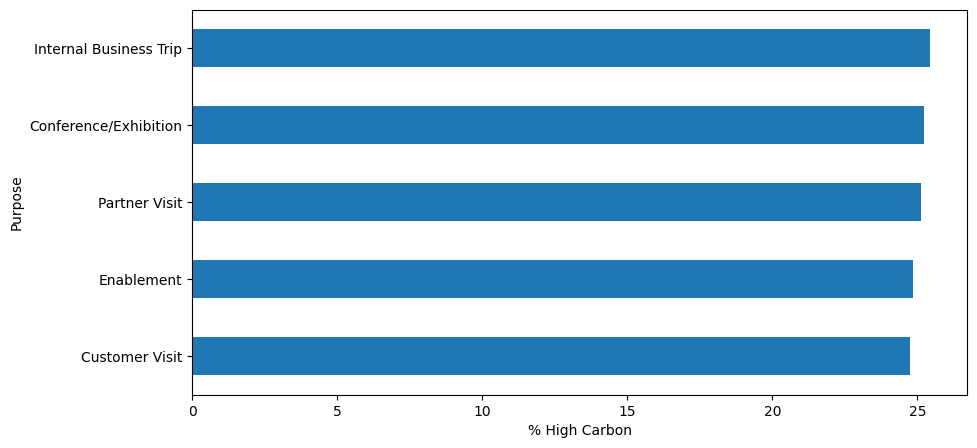

In [55]:
purpose_highcarbon = pd.crosstab(
    train_df["Purpose"],
    train_df["HighCarbon"],
    normalize="index"
) * 100

purpose_highcarbon[1].sort_values().plot(
    kind="barh",
    figsize=(10,5)
)

plt.xlabel("% High Carbon")

plt.show()

In [56]:
from scipy.stats import chi2_contingency

chi_square_results = []

for col in categorical_columns:

    contingency = pd.crosstab(train_df[col], train_df["HighCarbon"])

    chi2, p, dof, exp = chi2_contingency(contingency)

    chi_square_results.append([col, p])

chi_square_df = pd.DataFrame(
    chi_square_results,
    columns=["Feature", "P-value"]
)

chi_square_df.sort_values("P-value")

,Feature,P-value
0,DepartureLocationCountry,0.000000
1,DepartureLocationCity,0.000000
2,ArrivalLocationCountry,0.000000
3,ArrivalLocationCity,0.000000
4,ShippingTypeDescription,0.000000
6,OutOfPolicy,0.000000
8,BusinessUnit,0.325296
7,EmployeeNumber,0.393195
5,Purpose,0.665063


# Business Insights

### Initial Observations

- Flights contribute a larger share of high-carbon trips than other travel modes.
- Some Business Units consistently generate more high-carbon trips.
- Certain travel purposes are associated with higher emissions.
- A few countries and cities dominate the travel volume.
- Out-of-policy trips may have a higher likelihood of becoming high-carbon.
- These findings will guide feature engineering and also support the Celonis dashboard and presentation.

In [57]:
print("Event Log Shape")
print(event_log.shape)

print("\n")

print("Event Attribute Shape")
print(event_attr.shape)

Event Log Shape
(671547, 4)


Event Attribute Shape
(65289, 19)


In [58]:
event_log.head()

,TripID,StepOrder,EventName,EventTimestamp
0,1,1,Book Mode of Transportation,03/21/2024 23:36:20
1,1,2,Book Lodging,03/22/2024 09:16:16
2,1,3,Submit Travel Request,03/22/2024 12:15:19
3,1,4,Travel Request Approved,03/23/2024 08:12:58
4,1,5,Receive Confirmation,03/23/2024 23:42:47


In [59]:
event_attr.head()

,TripID,EmployeeNumber,TravelRequestID,ExpenseRequestID,ExpenseDenialReason,ExpenseReimbursementReason,ExpenseReimbursementAmount,ReasonForTransportCancellation,NewTransportSelection,ReasonForNewTransport,NewHotelSelection,ReasonForNewHotel,NewModeOfTransportation,TransportationPriceDifference,ReasonForTransportationChange,ReasonForDelay,ExtensionLength,DaysPreapproved,ProcessCode
0,1,M1000-M5008,TR000001,EXP000001,NaN,Policy exception approved,267.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,V1
1,3,M1000-M5030,TR000003,EXP000003,NaN,Partial reimbursement,526.90,Personal emergency,Rebooked flight,Better schedule,NaN,NaN,Updated First Class Flight,140.62,Time constraints,NaN,NaN,2,V1
2,6,M1000-M5069,TR000006,EXP000006,NaN,Policy exception approved,487.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Weather delay,NaN,1,V1
3,7,M1000-M5095,TR000007,EXP000007,NaN,Policy exception approved,511.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,V1
4,8,M1000-M5097,TR000008,EXP000008,NaN,Standard travel reimbursement,452.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mechanical issue,NaN,2,V20


In [60]:
event_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671547 entries, 0 to 671546
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   TripID          671547 non-null  int64 
 1   StepOrder       671547 non-null  int64 
 2   EventName       671547 non-null  object
 3   EventTimestamp  671547 non-null  object
dtypes: int64(2), object(2)
memory usage: 20.5+ MB


In [61]:
event_attr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65289 entries, 0 to 65288
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   TripID                          65289 non-null  int64  
 1   EmployeeNumber                  65289 non-null  object 
 2   TravelRequestID                 65289 non-null  object 
 3   ExpenseRequestID                64930 non-null  object 
 4   ExpenseDenialReason             10773 non-null  object 
 5   ExpenseReimbursementReason      64521 non-null  object 
 6   ExpenseReimbursementAmount      64930 non-null  float64
 7   ReasonForTransportCancellation  3871 non-null   object 
 8   NewTransportSelection           8986 non-null   object 
 9   ReasonForNewTransport           8986 non-null   object 
 10  NewHotelSelection               8828 non-null   object 
 11  ReasonForNewHotel               8828 non-null   object 
 12  NewModeOfTransportation         

In [62]:
event_log.isnull().sum().sort_values(ascending=False)

TripID            0
StepOrder         0
EventName         0
EventTimestamp    0
dtype: int64

In [63]:
event_attr.isnull().sum().sort_values(ascending=False)

ReasonForTransportCancellation    61418
ExtensionLength                   59300
ReasonForDelay                    58453
NewModeOfTransportation           57767
TransportationPriceDifference     57767
ReasonForTransportationChange     57767
NewHotelSelection                 56461
ReasonForNewHotel                 56461
ReasonForNewTransport             56303
NewTransportSelection             56303
ExpenseDenialReason               54516
ExpenseReimbursementReason          768
ExpenseRequestID                    359
ExpenseReimbursementAmount          359
DaysPreapproved                       0
TripID                                0
EmployeeNumber                        0
TravelRequestID                       0
ProcessCode                           0
dtype: int64

In [64]:
print("Duplicate rows in Event Log :", event_log.duplicated().sum())

print("Duplicate rows in Event Attributes :", event_attr.duplicated().sum())

Duplicate rows in Event Log : 0
Duplicate rows in Event Attributes : 0


In [65]:
print("Unique Trips in Event Log")

event_log["TripID"].nunique()

Unique Trips in Event Log


65289

In [66]:
event_log["EventName"].value_counts()

EventName
Book Mode of Transportation      68134
Submit Travel Request            65289
Travel Request Approved          62982
Receive Confirmation             62982
Submit Expense Request           62903
Expense Request Approved         62847
Expense Reimbursement            62847
Book Lodging                     59815
Take Departure Flight            41735
Take Return Flight               41735
Pickup Rental                    18166
Return Rental                    18166
Manager Preapproved              11331
Trip Extension                    5989
Itinerary Edit                    3729
Take Return Train                 3081
Take Departure Train              3081
Hotel Change                      2733
Mode of Transportation Change     2441
Ticket Reissued                   2301
Flight Change                     2222
Flight Delay                      1229
Flight Cancellation               1153
Vehicle Change                     953
Missed Flight                      895
Travel Delay   

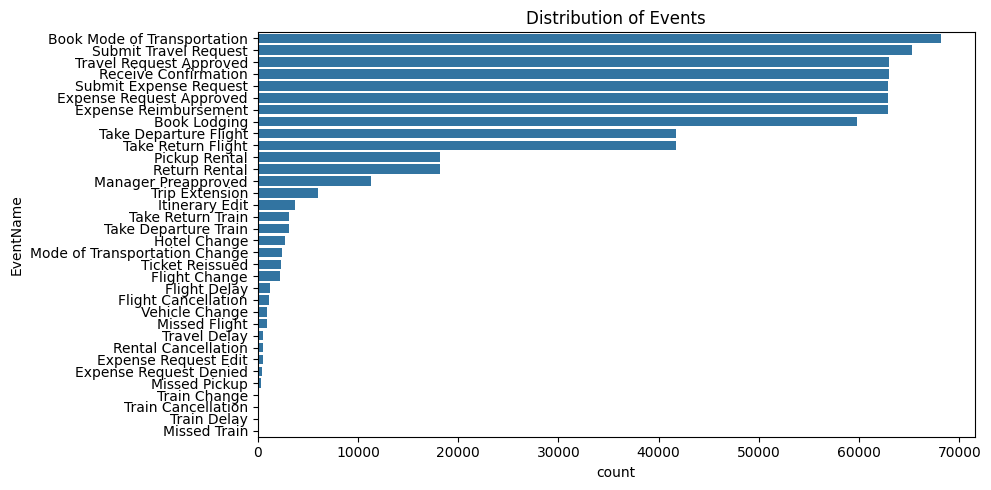

In [67]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=event_log,
    y="EventName",
    order=event_log["EventName"].value_counts().index
)

plt.title("Distribution of Events")

plt.tight_layout()

plt.show()

In [68]:
events_per_trip = event_log.groupby("TripID").size()

events_per_trip.describe()

count    65289.000000
mean        10.285760
std          1.311022
min          2.000000
25%         10.000000
50%         10.000000
75%         11.000000
max         14.000000
dtype: float64

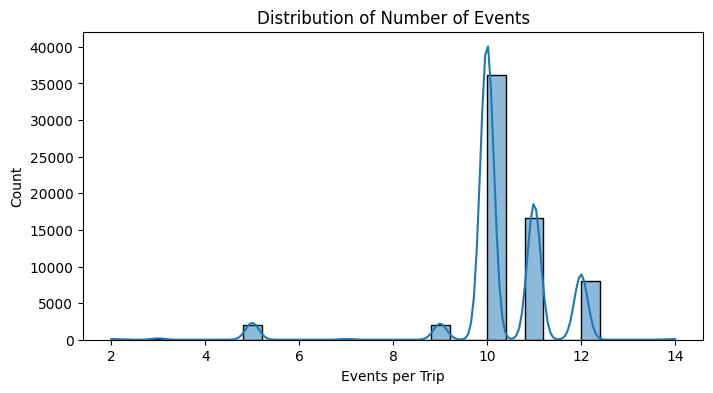

In [69]:
# Trips with Maximum Events

plt.figure(figsize=(8,4))

sns.histplot(events_per_trip,bins=30,kde=True)

plt.xlabel("Events per Trip")

plt.title("Distribution of Number of Events")

plt.show()

In [70]:
# Most Frequent Event
events_per_trip.sort_values(ascending=False).head(10)

TripID
67673    14
51125    14
37512    14
37509    14
63176    14
68663    14
6854     14
68669    14
18757    14
55466    14
dtype: int64

In [71]:
event_log["EventName"].value_counts().head(10)

EventName
Book Mode of Transportation    68134
Submit Travel Request          65289
Travel Request Approved        62982
Receive Confirmation           62982
Submit Expense Request         62903
Expense Request Approved       62847
Expense Reimbursement          62847
Book Lodging                   59815
Take Departure Flight          41735
Take Return Flight             41735
Name: count, dtype: int64

In [72]:
# Least Frequent Event
event_log["EventName"].value_counts().tail(10)

EventName
Missed Flight             895
Travel Delay              574
Rental Cancellation       522
Expense Request Edit      501
Expense Request Denied    427
Missed Pickup             376
Train Change              154
Train Cancellation        105
Train Delay                89
Missed Train               60
Name: count, dtype: int64

In [73]:
print("First Event Recorded :", event_log["EventTimestamp"].min())
print("Last Event Recorded :", event_log["EventTimestamp"].max())

First Event Recorded : 01/01/2024 00:02:43
Last Event Recorded : 12/31/2024 23:59:13


In [74]:
event_log["EventTimestamp"] = pd.to_datetime(
    event_log["EventTimestamp"],
    errors="coerce"
)

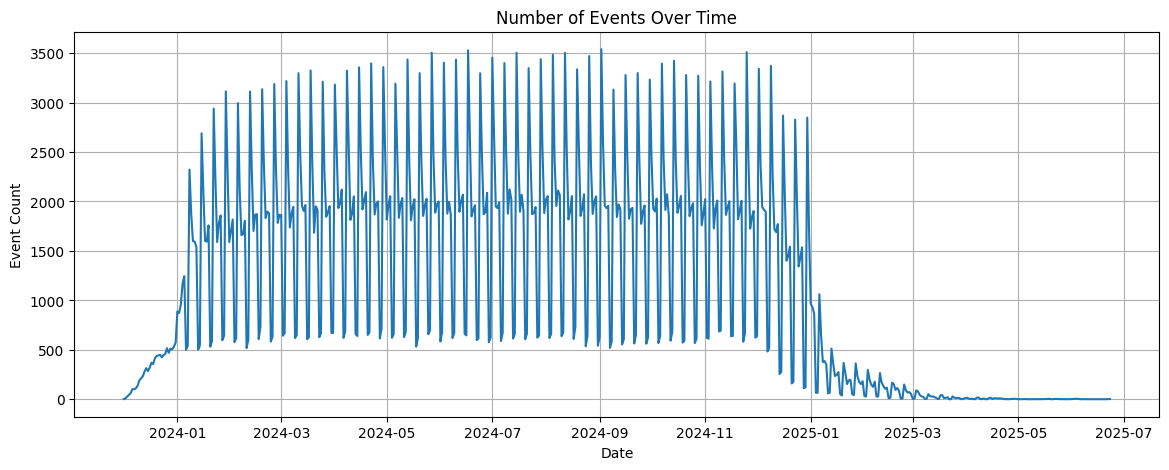

In [75]:
events_by_day = (
    event_log
    .groupby(event_log["EventTimestamp"].dt.date)
    .size()
)

plt.figure(figsize=(14,5))

events_by_day.plot()

plt.title("Number of Events Over Time")

plt.xlabel("Date")

plt.ylabel("Event Count")

plt.grid(True)

plt.show()

In [76]:
events_per_trip = (
    event_log
    .groupby("TripID")
    .size()
    .reset_index(name="NumberOfEvents")
)

events_per_trip.head()

,TripID,NumberOfEvents
0,1,10
1,3,10
2,6,10
3,7,10
4,8,11


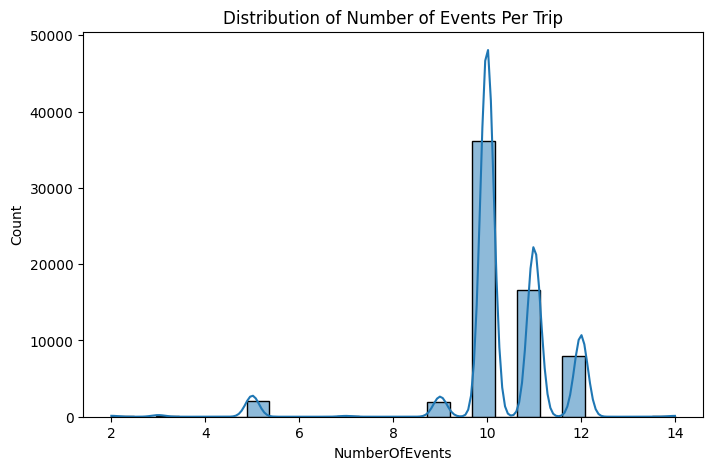

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(
    events_per_trip["NumberOfEvents"],
    bins=25,
    kde=True
)

plt.title("Distribution of Number of Events Per Trip")

plt.show()

In [78]:
events_per_trip.sort_values(
    by="NumberOfEvents",
    ascending=False
).head(10)

,TripID,NumberOfEvents
50732,67673,14
38287,51125,14
28050,37512,14
28047,37509,14
47338,63176,14
51479,68663,14
5107,6854,14
51483,68669,14
14005,18757,14
41571,55466,14


In [79]:
eda_df = train_df.merge(
    events_per_trip,
    on="TripID",
    how="left"
)

eda_df.head()

,TripID,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,...,BusinessUnit,HotelNights,NetCosts,Departure_CO2e,Return_CO2e,Hotel_CO2e,Spend_CO2e,TotalCO2e,HighCarbon,NumberOfEvents
0,1,CN,Beijing,IN,New Delhi,12,Business Class Flight,Customer Visit,No,9000,...,Services,1,900,1565.121857,1565.121857,58.9,1472.279257,3189.143714,0,10
1,3,US,New York,MX,Mexico City,11,First Class Flight,Customer Visit,Yes,6000,...,Sales,2,3600,743.295848,743.295848,38.6,2921.504761,1525.191696,0,10
2,6,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Conference/Exhibition,No,9000,...,Services,1,450,1053.713528,1053.713528,51.4,743.646219,2158.827056,0,10
3,7,DE,Berlin,FR,Paris,12,Business Class Flight,Customer Visit,No,10000,...,Executive Management,1,3450,196.262703,196.262703,6.7,3343.160260,399.225407,0,10
4,8,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Internal Business Trip,No,7000,...,Marketing,2,1500,1053.713528,1053.713528,102.8,2478.820729,2210.227056,0,11


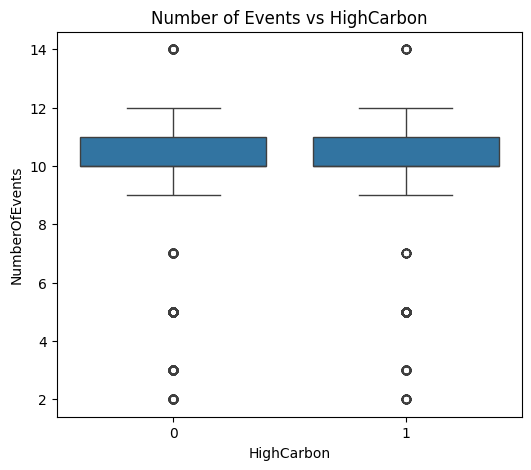

In [80]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=eda_df,
    x="HighCarbon",
    y="NumberOfEvents"
)

plt.title("Number of Events vs HighCarbon")

plt.show()

In [81]:
event_log["EventTimestamp"] = pd.to_datetime(
    event_log["EventTimestamp"],
    errors="coerce"
)

In [82]:
process_duration = (

    event_log

    .groupby("TripID")

    .agg(

        StartTime=("EventTimestamp","min"),

        EndTime=("EventTimestamp","max")

    )

)

process_duration["ProcessDurationHours"] = (

    process_duration["EndTime"] -

    process_duration["StartTime"]

).dt.total_seconds()/3600

process_duration.head()

,StartTime,EndTime,ProcessDurationHours
TripID,,,
1,2024-03-21 23:36:20,2024-04-17 11:10:09,635.563611
3,2024-12-08 21:38:00,2024-12-13 01:58:01,100.333611
6,2024-03-29 20:01:51,2024-04-18 18:20:31,478.311111
7,2024-11-23 19:37:31,2024-12-18 19:02:01,599.408333
8,2024-06-24 04:15:01,2024-07-18 07:57:59,579.716111


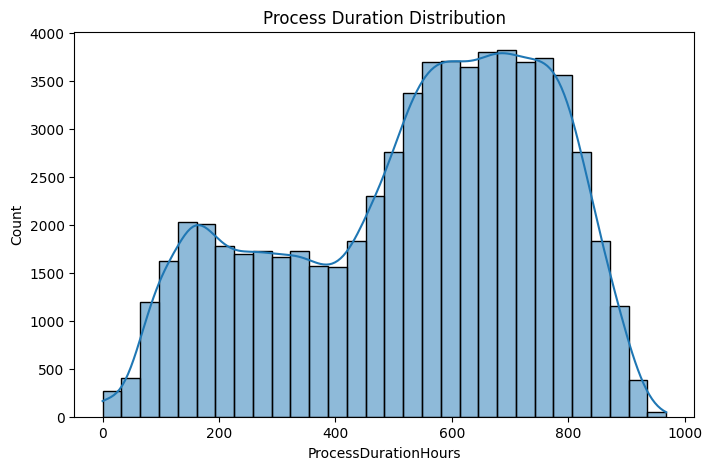

In [83]:
plt.figure(figsize=(8,5))

sns.histplot(
    process_duration["ProcessDurationHours"],
    bins=30,
    kde=True
)

plt.title("Process Duration Distribution")

plt.show()

In [84]:
eda_df = eda_df.merge(
    process_duration["ProcessDurationHours"],
    left_on="TripID",
    right_index=True,
    how="left"
)

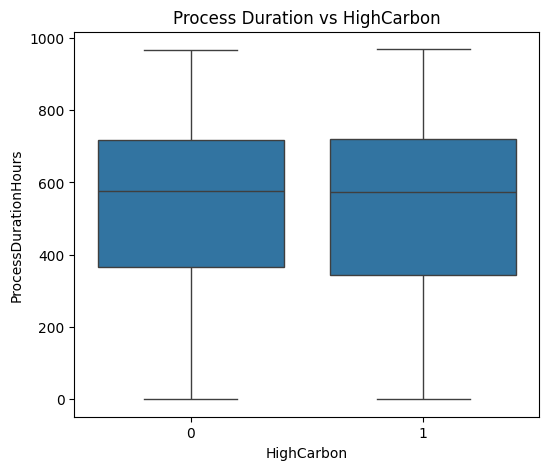

In [85]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=eda_df,
    x="HighCarbon",
    y="ProcessDurationHours"
)

plt.title("Process Duration vs HighCarbon")

plt.show()

In [86]:
event_attr.head()

,TripID,EmployeeNumber,TravelRequestID,ExpenseRequestID,ExpenseDenialReason,ExpenseReimbursementReason,ExpenseReimbursementAmount,ReasonForTransportCancellation,NewTransportSelection,ReasonForNewTransport,NewHotelSelection,ReasonForNewHotel,NewModeOfTransportation,TransportationPriceDifference,ReasonForTransportationChange,ReasonForDelay,ExtensionLength,DaysPreapproved,ProcessCode
0,1,M1000-M5008,TR000001,EXP000001,NaN,Policy exception approved,267.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,V1
1,3,M1000-M5030,TR000003,EXP000003,NaN,Partial reimbursement,526.90,Personal emergency,Rebooked flight,Better schedule,NaN,NaN,Updated First Class Flight,140.62,Time constraints,NaN,NaN,2,V1
2,6,M1000-M5069,TR000006,EXP000006,NaN,Policy exception approved,487.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Weather delay,NaN,1,V1
3,7,M1000-M5095,TR000007,EXP000007,NaN,Policy exception approved,511.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,V1
4,8,M1000-M5097,TR000008,EXP000008,NaN,Standard travel reimbursement,452.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mechanical issue,NaN,2,V20


In [87]:
missing = (

event_attr

.isnull()

.mean()

*100

).sort_values(ascending=False)

missing[missing>0]

ReasonForTransportCancellation    94.070977
ExtensionLength                   90.826939
ReasonForDelay                    89.529630
NewModeOfTransportation           88.478917
TransportationPriceDifference     88.478917
ReasonForTransportationChange     88.478917
NewHotelSelection                 86.478580
ReasonForNewHotel                 86.478580
ReasonForNewTransport             86.236579
NewTransportSelection             86.236579
ExpenseDenialReason               83.499518
ExpenseReimbursementReason         1.176308
ExpenseRequestID                   0.549863
ExpenseReimbursementAmount         0.549863
dtype: float64

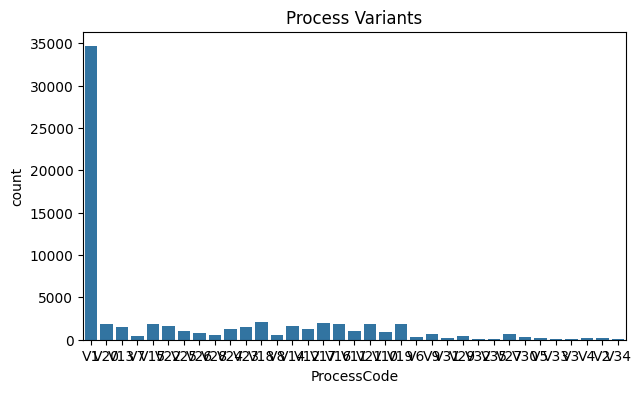

In [88]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=event_attr,
    x="ProcessCode"
)

plt.title("Process Variants")

plt.show()

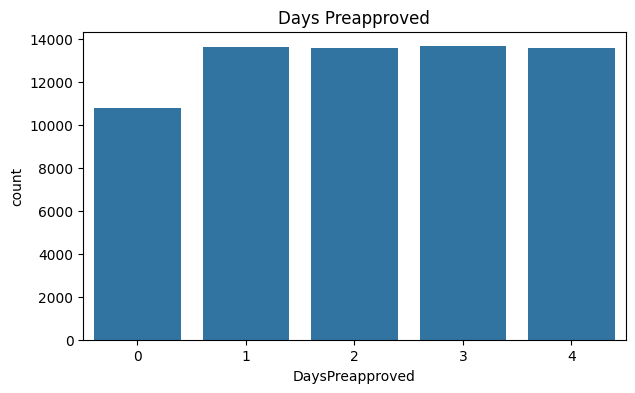

In [89]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=event_attr,
    x="DaysPreapproved"
)

plt.title("Days Preapproved")

plt.show()

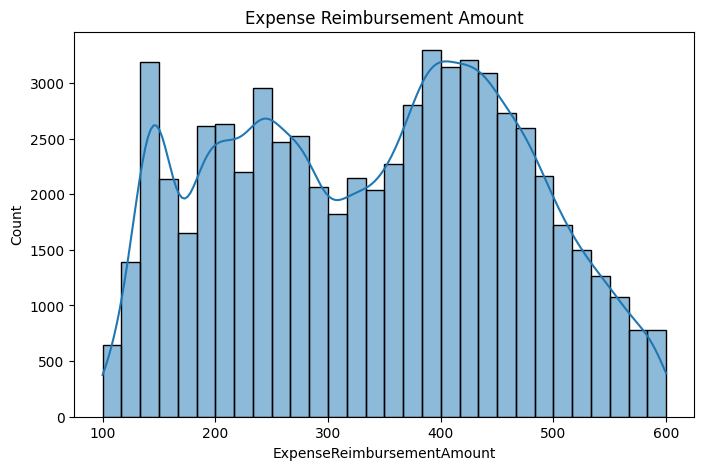

In [90]:
plt.figure(figsize=(8,5))

sns.histplot(
    event_attr["ExpenseReimbursementAmount"],
    bins=30,
    kde=True
)

plt.title("Expense Reimbursement Amount")

plt.show()

In [91]:
event_attr["ReasonForDelay"].value_counts(dropna=False)

ReasonForDelay
NaN                     58453
Weather delay            1700
Mechanical issue         1575
Airport congestion       1478
Security screening       1439
Traffic congestion        196
Rental desk queue         149
Vehicle breakdown         149
Technical difficulty       46
System downtime            44
Track maintenance          23
Platform delay             21
Station congestion         16
Name: count, dtype: int64

In [92]:
eda_df = eda_df.merge(
    event_attr,
    on="TripID",
    how="left"
)

eda_df.shape

(65289, 40)

In [93]:
eda_df[
[
"NumberOfEvents",
"ProcessDurationHours",
"DaysPreapproved",
"ExpenseReimbursementAmount",
"HighCarbon"
]
].corr()

,NumberOfEvents,ProcessDurationHours,DaysPreapproved,ExpenseReimbursementAmount,HighCarbon
NumberOfEvents,1.000000,0.302172,-0.006828,0.002705,-0.007967
ProcessDurationHours,0.302172,1.000000,-0.018474,-0.010635,-0.006517
DaysPreapproved,-0.006828,-0.018474,1.000000,-0.006505,0.003650
ExpenseReimbursementAmount,0.002705,-0.010635,-0.006505,1.000000,-0.004638
HighCarbon,-0.007967,-0.006517,0.003650,-0.004638,1.000000


In [94]:
eda_df.to_csv(
    "eda_dataset.csv",
    index=False
)

In [95]:
process_highcarbon = pd.crosstab(
    eda_df["ProcessCode"],
    eda_df["HighCarbon"],
    normalize="index"
) * 100

process_highcarbon

HighCarbon,0,1
ProcessCode,,
V1,74.968953,25.031047
V10,73.068433,26.931567
V11,78.878879,21.121121
V12,75.875796,24.124204
V13,75.068871,24.931129
V14,76.228998,23.771002
V15,75.883002,24.116998
V16,76.492147,23.507853
V17,76.862358,23.137642


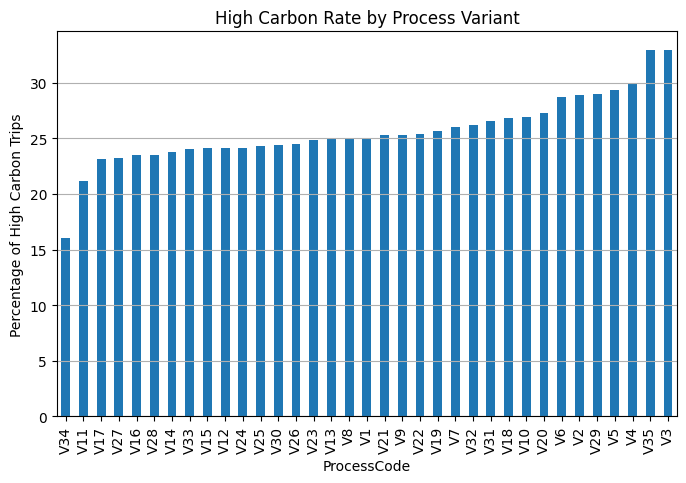

In [96]:
process_highcarbon[1].sort_values().plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Percentage of High Carbon Trips")

plt.title("High Carbon Rate by Process Variant")

plt.grid(axis="y")

plt.show()

In [97]:
days_preapproved = pd.crosstab(
    eda_df["DaysPreapproved"],
    eda_df["HighCarbon"],
    normalize="index"
) * 100

days_preapproved

HighCarbon,0,1
DaysPreapproved,,
0,75.473274,24.526726
1,74.785667,25.214333
2,74.836289,25.163711
3,75.464657,24.535343
4,74.509516,25.490484


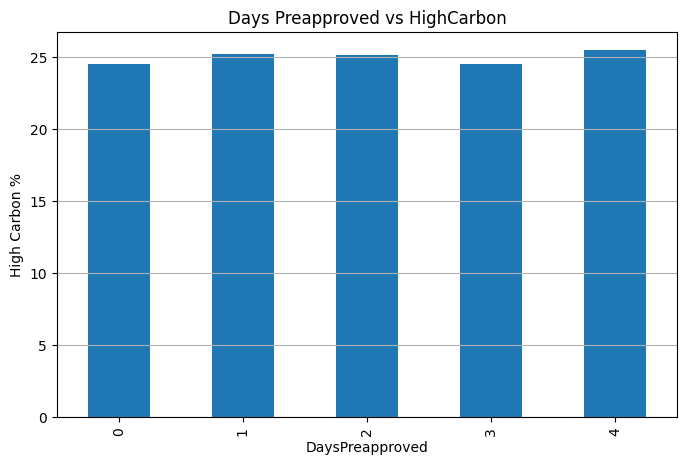

In [98]:
days_preapproved[1].plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("High Carbon %")

plt.title("Days Preapproved vs HighCarbon")

plt.grid(axis="y")

plt.show()

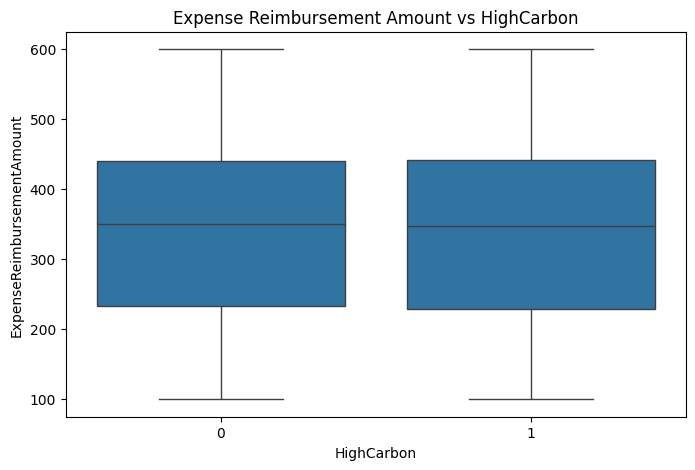

In [99]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="HighCarbon",
    y="ExpenseReimbursementAmount"
)

plt.title("Expense Reimbursement Amount vs HighCarbon")

plt.show()

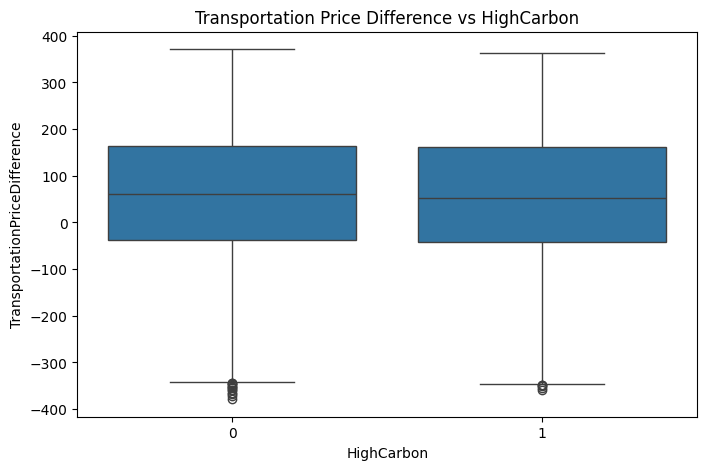

In [100]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="HighCarbon",
    y="TransportationPriceDifference"
)

plt.title("Transportation Price Difference vs HighCarbon")

plt.show()

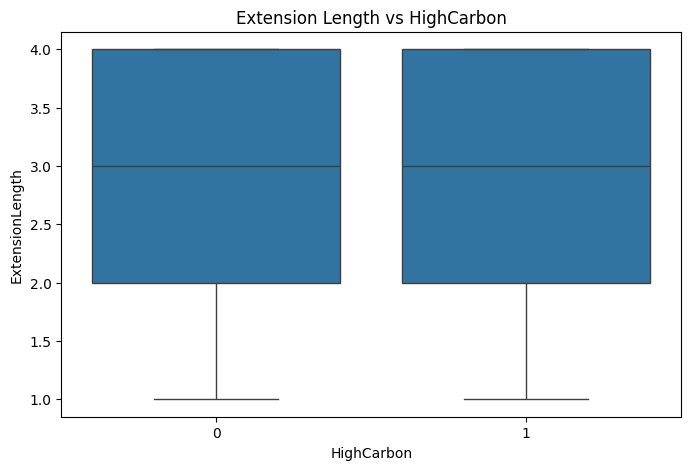

In [101]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="HighCarbon",
    y="ExtensionLength"
)

plt.title("Extension Length vs HighCarbon")

plt.show()

In [102]:
eda_df["ReasonForDelay"].value_counts(dropna=False)

ReasonForDelay
NaN                     58453
Weather delay            1700
Mechanical issue         1575
Airport congestion       1478
Security screening       1439
Traffic congestion        196
Rental desk queue         149
Vehicle breakdown         149
Technical difficulty       46
System downtime            44
Track maintenance          23
Platform delay             21
Station congestion         16
Name: count, dtype: int64

In [103]:
delay_highcarbon = pd.crosstab(
    eda_df["ReasonForDelay"],
    eda_df["HighCarbon"],
    normalize="index"
) * 100

delay_highcarbon

HighCarbon,0,1
ReasonForDelay,,
Airport congestion,67.523681,32.476319
Mechanical issue,66.095238,33.904762
Platform delay,100.000000,0.000000
Rental desk queue,93.959732,6.040268
Security screening,65.948575,34.051425
Station congestion,100.000000,0.000000
System downtime,56.818182,43.181818
Technical difficulty,65.217391,34.782609
Track maintenance,100.000000,0.000000


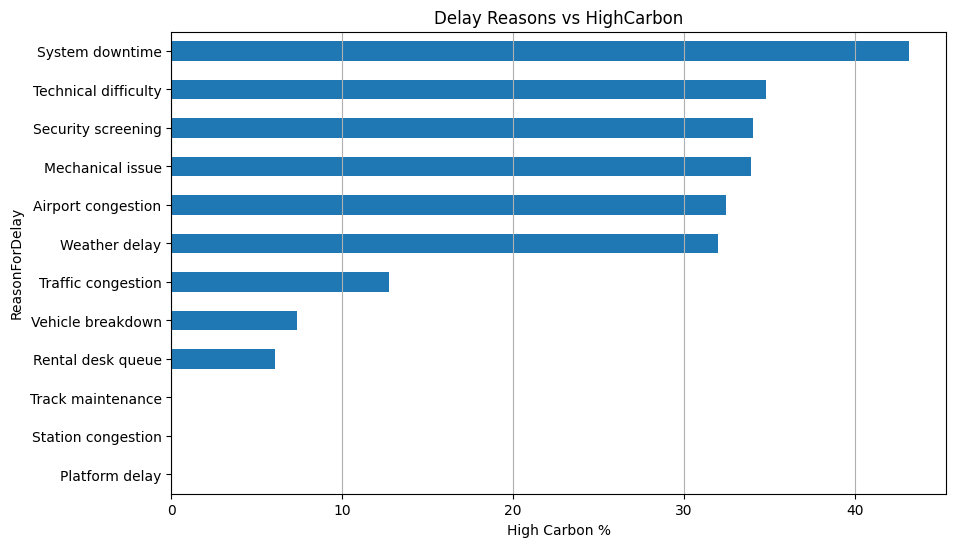

In [104]:
delay_highcarbon[1].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.xlabel("High Carbon %")

plt.title("Delay Reasons vs HighCarbon")

plt.grid(axis="x")

plt.show()

In [105]:
eda_df["ReasonForTransportationChange"].value_counts(dropna=False)

ReasonForTransportationChange
NaN                  57767
Cost optimization     1905
Client preference     1889
Time constraints      1867
Safety concern        1861
Name: count, dtype: int64

In [106]:
transport_change = pd.crosstab(
    eda_df["ReasonForTransportationChange"],
    eda_df["HighCarbon"],
    normalize="index"
) * 100

transport_change

HighCarbon,0,1
ReasonForTransportationChange,,
Client preference,73.636845,26.363155
Cost optimization,75.958005,24.041995
Safety concern,74.959699,25.040301
Time constraints,75.843599,24.156401


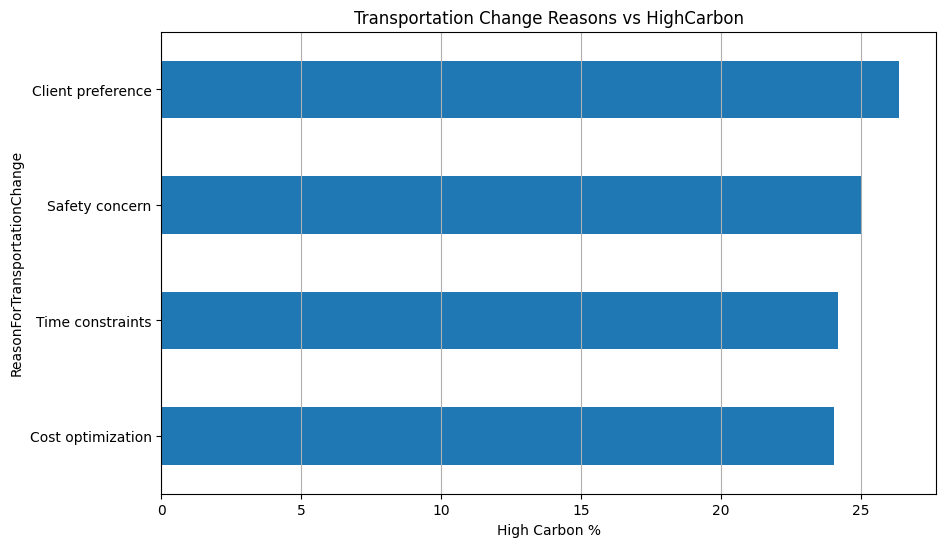

In [107]:
transport_change[1].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.xlabel("High Carbon %")

plt.title("Transportation Change Reasons vs HighCarbon")

plt.grid(axis="x")

plt.show()

In [108]:
eda_df["ReasonForTransportCancellation"].value_counts(dropna=False)

ReasonForTransportCancellation
NaN                           61418
Personal emergency             1027
Weather disruption              819
Operational issue               818
Airline schedule change         771
Vehicle issue                   183
Rental availability change      174
Train schedule change            34
Track maintenance                32
Schedule change                  13
Name: count, dtype: int64

In [109]:
cancel_highcarbon = pd.crosstab(
    eda_df["ReasonForTransportCancellation"],
    eda_df["HighCarbon"],
    normalize="index"
) * 100

cancel_highcarbon

HighCarbon,0,1
ReasonForTransportCancellation,,
Airline schedule change,67.185473,32.814527
Operational issue,66.014670,33.985330
Personal emergency,71.567673,28.432327
Rental availability change,87.931034,12.068966
Schedule change,76.923077,23.076923
Track maintenance,100.000000,0.000000
Train schedule change,100.000000,0.000000
Vehicle issue,92.896175,7.103825
Weather disruption,64.835165,35.164835


In [110]:
event_sequences = (
    event_log
    .sort_values(["TripID", "StepOrder"])
    .groupby("TripID")["EventName"]
    .apply(lambda x: " → ".join(x))
)

event_sequences.head()

TripID
1    Book Mode of Transportation → Book Lodging → S...
3    Book Mode of Transportation → Book Lodging → S...
6    Book Mode of Transportation → Book Lodging → S...
7    Book Mode of Transportation → Book Lodging → S...
8    Manager Preapproved → Book Mode of Transportat...
Name: EventName, dtype: object

In [111]:
event_sequences.value_counts().head(20)

EventName
Book Mode of Transportation → Book Lodging → Submit Travel Request → Travel Request Approved → Receive Confirmation → Take Departure Flight → Take Return Flight → Submit Expense Request → Expense Request Approved → Expense Reimbursement                                                        23017
Book Mode of Transportation → Book Lodging → Submit Travel Request → Travel Request Approved → Receive Confirmation → Pickup Rental → Return Rental → Submit Expense Request → Expense Request Approved → Expense Reimbursement                                                                      9945
Manager Preapproved → Trip Extension → Book Mode of Transportation → Book Lodging → Submit Travel Request                                                                                                                                                                                            2060
Book Mode of Transportation → Book Lodging → Submit Travel Request → Travel Request Approved → R

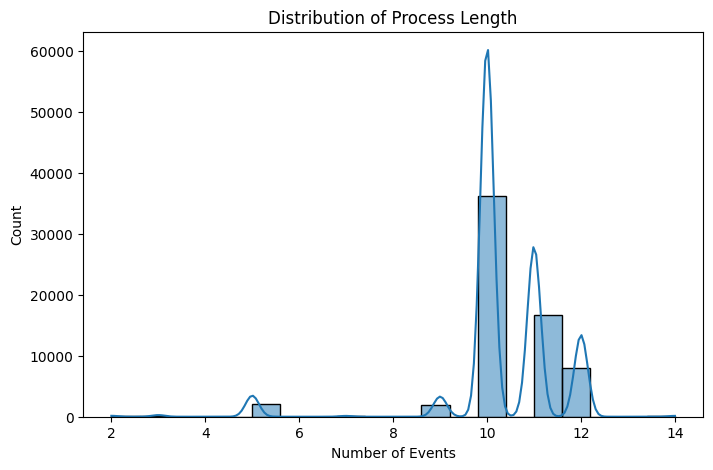

In [112]:
sequence_length = (
    event_log
    .groupby("TripID")
    .size()
)

plt.figure(figsize=(8,5))

sns.histplot(
    sequence_length,
    bins=20,
    kde=True
)

plt.title("Distribution of Process Length")

plt.xlabel("Number of Events")

plt.show()

# Feature Engineering

In [113]:
event_counts = event_log.groupby('TripID').size().reset_index(name='NumberOfEvents')

event_log['EventTimestamp'] = pd.to_datetime(event_log['EventTimestamp'])
timestamps = event_log.groupby('TripID')['EventTimestamp'].agg(['min', 'max']).reset_index()
timestamps['ProcessDurationHours'] = (timestamps['max'] - timestamps['min']).dt.total_seconds() / 3600.0

event_features = pd.merge(event_counts, timestamps[['TripID', 'ProcessDurationHours']], on='TripID', how='left')

train_df = pd.merge(train_df, event_features, on='TripID', how='left')
test_df = pd.merge(test_df, event_features, on='TripID', how='left')

In [114]:
# Prohibit leakage metrics that directly expose or highly correlate with the label
leakage_cols = ['Departure_CO2e', 'Return_CO2e', 'Hotel_CO2e', 'Spend_CO2e', 'TotalCO2e']
train_df.drop(columns=[col for col in leakage_cols if col in train_df.columns], inplace=True)

y = train_df['HighCarbon']
X_full = train_df.drop(columns=['HighCarbon'])
X_private = test_df.copy()

# Droppimg unnecessary individual identifier columns to avoid overfitting
unnecessary_ids = ['TripID', 'EmployeeNumber']
for col in unnecessary_ids:
    if col in X_full.columns:
        X_full.drop(columns=[col], inplace=True)
    if col in X_private.columns:
        X_private.drop(columns=[col], inplace=True)

In [115]:
def engineer_features(df):
    # Core domain features
    df['IsInternational'] = (df['DepartureLocationCountry'] != df['ArrivalLocationCountry']).astype(int)
    df['HasHotelStay'] = (df['HotelNights'] > 0).astype(int)
    
    # Calculate cost per night safely
    df['CostPerNight'] = np.where(df['HotelNights'] > 0, df['NetCosts'] / df['HotelNights'], 0)
    
    # Extra EDA Feature: Long Haul/Aviation Indicator (strongly tied to high emissions)
    flight_indicators = ['Business Class Flight', 'First Class Flight', 'Economy Flight']
    df['IsFlight'] = df['ShippingTypeDescription'].isin(flight_indicators).astype(int)
    
    return df

X_full = engineer_features(X_full)
X_private = engineer_features(X_private)

# Missing-Value Treatment

In [118]:
num_cols = X_full.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_full.select_dtypes(include=['object']).columns.tolist()

for col in num_cols:
    median_val = X_full[col].median()
    X_full[col] = X_full[col].fillna(median_val)
    X_private[col] = X_private[col].fillna(median_val)

for col in cat_cols:
    X_full[col] = X_full[col].fillna("Unknown")
    X_private[col] = X_private[col].fillna("Unknown")

In [117]:
# Grouping rare categories into one bucket
threshold = 0.01  
for col in cat_cols:
    freqs = X_full[col].value_counts(normalize=True)
    rare_categories = freqs[freqs < threshold].index
    
    X_full[col] = X_full[col].replace(rare_categories, 'Other')
    X_private[col] = X_private[col].replace(rare_categories, 'Other')

In [120]:
# One Hot Encoding
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_full[cat_cols])

encoded_train_cats = pd.DataFrame(encoder.transform(X_full[cat_cols]), columns=encoder.get_feature_names_out(cat_cols))
encoded_private_cats = pd.DataFrame(encoder.transform(X_private[cat_cols]), columns=encoder.get_feature_names_out(cat_cols))

X_full_unscaled = pd.concat([X_full[num_cols].reset_index(drop=True), encoded_train_cats], axis=1)
X_private_unscaled = pd.concat([X_private[num_cols].reset_index(drop=True), encoded_private_cats], axis=1)

In [123]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_full_unscaled[num_cols])

X_full_scaled = X_full_unscaled.copy()
X_private_scaled = X_private_unscaled.copy()

# Applying transform strictly to numerical features
X_full_scaled[num_cols] = scaler.transform(X_full_unscaled[num_cols])
X_private_scaled[num_cols] = scaler.transform(X_private_unscaled[num_cols])

In [125]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_full_unscaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

X_train shape: (52231, 98) | X_test shape: (13058, 98)


In [128]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [146]:
random_state = 42
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=random_state),
    "Decision Tree": DecisionTreeClassifier(random_state=random_state),
    "Random Forest": RandomForestClassifier(random_state=random_state, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(random_state=random_state, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=random_state),
    "XGBoost": XGBClassifier(n_estimators=200,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,reg_alpha=0.1,reg_lambda=2.0,random_state=42,eval_metric="logloss",n_jobs=-1),
}

In [147]:
results_data = []


for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
        
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results_data.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...
Training XGBoost...


In [149]:
results_df = pd.DataFrame(results_data)

results_df = results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

styled_results = results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}).background_gradient(cmap='Blues', subset=['ROC-AUC', 'F1-Score'])

styled_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.9936,0.9898,0.9844,0.9871,0.9990
1,Random Forest,0.9931,0.9889,0.9835,0.9862,0.9989
2,Extra Trees,0.9919,0.9880,0.9795,0.9837,0.9985
3,Gradient Boosting,0.9897,0.9900,0.9685,0.9791,0.9985
4,Logistic Regression,0.9551,0.9545,0.8616,0.9057,0.9898
5,Decision Tree,0.9874,0.9734,0.9761,0.9748,0.9836


### Choosing XGBoost as our Model as it gives the best results
No need for HyperParameter Tuning as already we have a pretty high ROC-AUC score

In [155]:
# Load raw sets to match pipeline rules from scratch safely
train_df = pd.read_csv('public_trip_data.csv')
test_df = pd.read_csv('private_trip_data.csv')
event_log = pd.read_csv('public_trip_event_log.csv')

In [156]:
event_counts = event_log.groupby('TripID').size().reset_index(name='NumberOfEvents')

event_log['EventTimestamp'] = pd.to_datetime(event_log['EventTimestamp'])
timestamps = event_log.groupby('TripID')['EventTimestamp'].agg(['min', 'max']).reset_index()
timestamps['ProcessDurationHours'] = (timestamps['max'] - timestamps['min']).dt.total_seconds() / 3600.0
event_features = pd.merge(event_counts, timestamps[['TripID', 'ProcessDurationHours']], on='TripID', how='left')

train_df = pd.merge(train_df, event_features, on='TripID', how='left')
test_df = pd.merge(test_df, event_features, on='TripID', how='left')

# Drop leakage variables to establish clean baseline frames
leakage_cols = ['Departure_CO2e', 'Return_CO2e', 'Hotel_CO2e', 'Spend_CO2e', 'TotalCO2e']
train_df.drop(columns=[col for col in leakage_cols if col in train_df.columns], inplace=True)

X_final_train = train_df.drop(columns=['HighCarbon'])
X_private = test_df.copy()

# Drop identifiers to avoid model overfitting
unnecessary_ids = ['TripID', 'EmployeeNumber']
for col in unnecessary_ids:
    if col in X_final_train.columns: X_final_train.drop(columns=[col], inplace=True)
    if col in X_private.columns: X_private.drop(columns=[col], inplace=True)

In [157]:
def engineer_features(df):
    df['IsInternational'] = (df['DepartureLocationCountry'] != df['ArrivalLocationCountry']).astype(int)
    df['HasHotelStay'] = (df['HotelNights'] > 0).astype(int)
    df['CostPerNight'] = np.where(df['HotelNights'] > 0, df['NetCosts'] / df['HotelNights'], 0)
    flight_indicators = ['Business Class Flight', 'First Class Flight', 'Economy Flight']
    df['IsFlight'] = df['ShippingTypeDescription'].isin(flight_indicators).astype(int)
    return df

X_final_train = engineer_features(X_final_train)
X_private = engineer_features(X_private)

# Dynamic numerical and categorical column separation
num_cols = X_final_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_final_train.select_dtypes(include=['object']).columns.tolist()

# Impute missing cells based on training properties
for col in num_cols:
    median_val = X_final_train[col].median()
    X_private[col] = X_private[col].fillna(median_val)

for col in cat_cols:
    X_final_train[col] = X_final_train[col].fillna("Unknown")
    X_private[col] = X_private[col].fillna("Unknown")

# Handle rare high-cardinality categorical values 
threshold = 0.01  
for col in cat_cols:
    freqs = X_final_train[col].value_counts(normalize=True)
    rare_categories = freqs[freqs < threshold].index
    X_final_train[col] = X_final_train[col].replace(rare_categories, 'Other')
    X_private[col] = X_private[col].replace(rare_categories, 'Other')

In [158]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_final_train[cat_cols])

encoded_train_cats = pd.DataFrame(encoder.transform(X_final_train[cat_cols]), columns=encoder.get_feature_names_out(cat_cols))
encoded_private_cats = pd.DataFrame(encoder.transform(X_private[cat_cols]), columns=encoder.get_feature_names_out(cat_cols))

# Concatenate numerical and encoded components
X_final_train_ready = pd.concat([X_final_train[num_cols].reset_index(drop=True), encoded_train_cats], axis=1)
X_private_ready = pd.concat([X_private[num_cols].reset_index(drop=True), encoded_private_cats], axis=1)

# Enforce identical schema shape, columns layout, and feature sorting order
X_private_processed = X_private_ready.reindex(columns=X_final_train_ready.columns, fill_value=0)

print(f"X_private_processed successfully created. Shape: {X_private_processed.shape}")

X_private_processed successfully created. Shape: (21764, 98)


In [161]:
y_final_train = train_df['HighCarbon'].values.ravel()

best_params = {
    'n_estimators': 200,
    'max_depth': 5,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 2.0,
    'random_state': 42,
    'eval_metric': 'logloss',
    'n_jobs': -1
}

final_model = XGBClassifier(**best_params)

In [162]:
# Training the model using the fully aligned training matrix and targets
final_model.fit(X_final_train_ready, y_final_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [163]:
# Predicting binary classifications (0 = Low Carbon, 1 = High Carbon)
private_predictions = final_model.predict_proba(X_private_processed)[:,1]

In [167]:
submission = pd.DataFrame({
    'TripID': test_df['TripID'],
    'HighCarbon': private_predictions
})

submission.to_csv('submission.csv', index=False)

In [168]:
print(submission.shape)

print(submission.isnull().sum())

print(submission["HighCarbon"].describe())

submission.head()

(21764, 2)
TripID        0
HighCarbon    0
dtype: int64
count    21764.000000
mean         0.248984
std          0.407917
min          0.000175
25%          0.002761
50%          0.007895
75%          0.216788
max          0.998909
Name: HighCarbon, dtype: float64


,TripID,HighCarbon
0,2,0.968740
1,4,0.008739
2,5,0.852693
3,14,0.005491
4,15,0.005391
